# 03 · Doğrusal Sınıflandırma Ailesi: Lojistik Regresyon, Diskriminant Analizi, Perceptron ve SGD (Linear Classification Family)
**Classical ML Lab** · Karar Sınırını Doğrudan/Dolaylı Öğrenen Dört Farklı Felsefe

---
> **Bu notebook'ta ne öğreneceğiz?**
> `02_linear_regression_family`'de sürekli (continuous) bir hedefi tahmin eden doğrusal modelleri işledik. Bu notebook'ta aynı doğrusal iskeleti ($\eta = X\beta$) **kategorik bir hedefi** (sınıf etiketini) tahmin etmek için nasıl kullandığımızı, dört farklı felsefeyle görüyoruz:
>
> - **Lojistik Regresyon (Logistic Regression):** Doğrudan $P(y=1\mid x)$ olasılığını modelleyen **ayırt edici (discriminative)** yaklaşım — sigmoid/softmax bağlantı fonksiyonu, düzenlileştirme (L1/L2/Elastic Net), ikili ve çok sınıflı (multinomial) versiyonlar
> - **Diskriminant Analizi (LDA/QDA):** Önce her sınıfın veriyi nasıl "ürettiğini" (Gauss dağılımı) modelleyip sonra Bayes teoremiyle sınıf olasılığına dönen **üretici (generative)** yaklaşım
> - **Perceptron:** Olasılık üretmeyen, sadece "hangi taraf" sorusuna cevap veren en eski (1958) doğrusal sınıflandırıcı — yapay sinir ağlarının atası
> - **SGDClassifier:** Kayıp fonksiyonunu değiştirerek yukarıdaki yöntemlerin birçoğunu **tek bir optimizasyon çerçevesinde** (stokastik gradyan inişi) birleştiren, büyük ölçekli/çevrimiçi (online) öğrenmeye uygun genel araç

>
> Her bölümü, o yöntemin **gerçekten hangi endüstride, hangi karara** hizmet ettiğini göstererek işliyoruz (kredi skorlama, tıbbi teşhis, sahtecilik/güvenlik, reklam teklifi optimizasyonu) — amaç "bu yöntemi ne zaman seçerim?" sorusuna iş hayatında cevap verebilmek. Değerlendirme metriklerinin (ROC/AUC, precision-recall, kalibrasyon) derinlemesine işlendiği yer `10_model_evaluation_metrics` olacak — burada temel accuracy/confusion matrix ile karşılaştırma yapıp modellerin **kendisine** odaklanıyoruz.
>
> **Önkoşul:** `02_linear_regression_family` (doğrusal öngörücü kavramı, düzenlileştirme, GLM bağlantı fonksiyonları), `01_data_prepreparation` (ölçekleme, encoding)
> **Veri:** Breast Cancer Wisconsin Diagnostic (UCI/sklearn), Wine Recognition (UCI/sklearn), Optical Recognition of Handwritten Digits (UCI/sklearn)
> **Araçlar:** Python (`scikit-learn`, `statsmodels`), R (`stats::glm`, `nnet::multinom`, `MASS::lda`/`qda`), SQL (`DuckDB`)

---
## 1 · Genel Çerçeve: Sınıflandırma Problemi ve Dört Felsefe

Regresyonda hedef $y \in \mathbb{R}$ iken, sınıflandırmada hedef $y \in \{1, \dots, K\}$ gibi **ayrık bir küme**dir. Sorun görünüşte basit ("hangi sınıfa ait?") ama yöntemler bu soruyu birbirinden çok farklı şekillerde cevaplıyor. Bu farkı iki eksende özetleyebiliriz:

| Eksen | Soru | Örnek |
|---|---|---|
| **Ayırt edici mi, üretici mi? (Discriminative vs Generative)** | Model doğrudan $P(y\mid x)$'i mi öğreniyor, yoksa önce $P(x\mid y)$'yi modelleyip Bayes teoremiyle mi $P(y\mid x)$'e ulaşıyor? | Lojistik Regresyon/Perceptron/SGD = ayırt edici; LDA/QDA = üretici |
| **Karar sınırı şekli** | Sınıfları ayıran sınır doğrusal mı, ikinci dereceden mi? | Lojistik Regresyon, LDA, Perceptron = doğrusal; QDA = ikinci dereceden (quadratic) |

Aşağıdaki tablo bu notebook'ta işleyeceğimiz dört yöntemi konumlandırıyor:

| Yöntem | Tip | Karar Sınırı | Olasılık Çıktısı | Kayıp Fonksiyonu |
|---|---|---|---|---|
| Lojistik Regresyon | Ayırt edici | Doğrusal | Var (kalibrasyona ihtiyaç duyabilir) | Log-kayıp (cross-entropy) |
| LDA | Üretici | Doğrusal | Var (Gauss varsayımı altında) | Yok — MLE ile kapalı-form kovaryans/ortalama tahmini |
| QDA | Üretici | İkinci dereceden | Var (Gauss varsayımı altında) | Yok — sınıf-bazlı kapalı-form tahmin |
| Perceptron | Ayırt edici | Doğrusal | **Yok** — sadece işaret (sign) | Perceptron kaybı (yanlış sınıflandırılanlar üzerinden) |
| SGDClassifier | Ayırt edici | Doğrusal | `loss` parametresine bağlı | Değişken — `hinge`/`log_loss`/`perceptron`/... |

**Neden hepsi "doğrusal aile"?** Çünkü hepsi (QDA hariç) temelde bir $\eta = X\beta$ doğrusal öngörücüsü hesaplayıp, kararı bu tek boyutlu skorun işaretine ya da bir eşiğe göre veriyor — `02_linear_regression_family`'deki aynı iskelet, farklı bir kayıp/karar kuralıyla sınıflandırmaya uyarlanıyor. QDA, kovaryans matrislerini sınıf başına ayrı tuttuğu için sınıra bir ikinci dereceden terim ekliyor, ama o da yine LDA'nın doğal bir genellemesi.

---
## 2 · Lojistik Regresyon (Logistic Regression) — Derinlemesine

### 2.1 İkili Lojistik Regresyon: Sigmoid ve Olabilirlik
Doğrusal öngörücü $\eta = X\beta$'yı doğrudan olasılık olarak kullanamayız çünkü $\eta \in (-\infty, \infty)$ ama olasılık $[0,1]$ aralığında olmalı. Lojistik regresyon bu geçişi **sigmoid (lojistik) fonksiyon** ile yapar:
$$P(y=1 \mid x) = \sigma(\eta) = \frac{1}{1 + e^{-\eta}} = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \dots + \beta_p x_p)}}$$
Bu, `02_linear_regression_family`'deki GLM çerçevesindeki **logit bağlantı fonksiyonunun** ($\log\frac{p}{1-p} = \eta$) ters çevrilmiş hâlidir — lojistik regresyon aslında hedef değişkeni Bernoulli dağılımına, bağlantı fonksiyonu logit olan bir GLM'dir.

Katsayılar, kareler toplamını değil **log-olabilirliği (log-likelihood)** maksimize ederek (Maximum Likelihood Estimation) bulunur:
$$\hat\beta = \arg\max_\beta \sum_{i=1}^n \Big[y_i \log \sigma(\eta_i) + (1-y_i)\log(1-\sigma(\eta_i))\Big]$$
Bu ifadenin negatifi **log-kayıp (log loss / binary cross-entropy)** olarak da bilinir — sklearn'ün optimize ettiği kayıp fonksiyonu tam olarak budur. OLS'in aksine kapalı-form çözüm yoktur; sayısal optimizasyon (Newton-Raphson, L-BFGS, SAGA, ...) gerekir.

### 2.2 Karar Sınırı ve Katsayı Yorumu: Odds Ratio
$P(y=1\mid x) = 0.5$ noktası tam olarak $\eta=0$'a karşılık gelir — yani karar sınırı $X\beta=0$ ile tanımlanan bir **hiperdüzlemdir (hyperplane)**, doğrusal regresyondaki fit doğrusunun sınıflandırma karşılığı. Katsayıları yorumlamanın en sezgisel yolu **odds (bahis oranı)** üzerinden gider: $\text{odds} = p/(1-p)$ olmak üzere
$$\log(\text{odds}) = \eta \quad\Rightarrow\quad \text{odds} = e^{\eta} \quad\Rightarrow\quad e^{\beta_j}: \; x_j\text{'de 1 birimlik artış, odds'u } e^{\beta_j} \text{ kat çarpar}$$
$e^{\beta_j} > 1$ ise $x_j$ artışı pozitif sınıf olasılığını artırıyor, $e^{\beta_j} < 1$ ise azaltıyor demektir — buna **odds ratio (OR)** denir ve özellikle tıp/epidemiyolojide standart raporlama birimidir ("sigara içenlerde hastalık riski OR=3.2 kat" gibi).

**Endüstride nerede kullanılır?** Lojistik regresyon, **kredi skorlama (credit scoring)**'de hâlâ endüstri standardıdır — bankalar "bu müşteri temerrüde düşer mi?" sorusunu yorumlanabilir katsayılarla (regülatörlere açıklanabilir olması şart) modellemek için tercih eder. **Tıbbi teşhis**te (bu bölümde kullanacağımız Breast Cancer Wisconsin verisi tam olarak bu senaryo — tümör iyi huylu mu kötü huylu mu?), **pazarlama tepki modellemesi**nde (bir kampanyaya tıklayacak mı/dönüşüm sağlayacak mı?) ve **churn (müşteri kaybı) tahmini**nde standart ilk-tercih modeldir.

### 2.3 Düzenlileştirme: L1, L2 ve Elastic Net
Tıpkı Ridge/Lasso'da olduğu gibi, log-olabilirliğe bir ceza terimi eklenerek katsayı büyüklüğü kısıtlanabilir:
$$\hat\beta = \arg\min_\beta \Big[-\text{log-likelihood}(\beta) + \frac{1}{C}\big(\alpha\|\beta\|_1 + (1-\alpha)\|\beta\|_2^2 \big)\Big]$$
sklearn'de bu, `C` (ceza *gücünün tersi* — küçük `C` = güçlü düzenlileştirme) ve `l1_ratio` ($\alpha$, 0=saf L2, 1=saf L1, arası=Elastic Net) parametreleriyle kontrol edilir. Mantık `02_linear_regression_family`'deki Ridge/Lasso ile birebir aynı: L2 katsayıları küçültür ama sıfırlamaz (çoklu bağlantıya karşı dayanıklılık), L1 bazı katsayıları tam sıfıra çeker (otomatik özellik seçimi). Yüksek boyutlu veride (örn. genomik, metin — binlerce özellik, göreceli az gözlem) düzenlileştirme neredeyse zorunludur; aksi hâlde MLE **tam/yarı-ayrışma (complete/quasi-separation)** denen bir soruna girip katsayılar sonsuza kaçmaya çalışır.

**Endüstride nerede kullanılır?** Metin sınıflandırma (spam filtreleme, duygu analizi) çok sayıda seyrek (sparse) kelime-özelliği içerdiği için L1-düzenlileştirilmiş lojistik regresyon klasik bir temel (baseline) modeldir; genomik/biyoinformatikte gen ifadesi verileriyle hastalık sınıflandırmasında da aynı sebeple L1 tercih edilir.

### 2.4 Çok Sınıflı Lojistik Regresyon: Softmax (Multinomial) vs One-vs-Rest
İki sınıftan fazlası olduğunda iki yaklaşım vardır:
- **One-vs-Rest (OvR):** Her sınıf için "bu sınıf mı, değil mi?" diye $K$ ayrı ikili lojistik regresyon eğitilir, tahminde en yüksek olasılığı veren sınıf seçilir. Basit ama olasılıklar sınıflar arasında tutarlı bir şekilde 1'e toplanmayabilir (ayrı ayrı kalibre edilir).
- **Softmax (Multinomial) Regresyon:** Tüm sınıflar **tek bir ortak optimizasyonla**, her sınıf için ayrı bir $\beta_k$ vektörü olacak şekilde eğitilir:
$$P(y=k\mid x) = \frac{e^{\eta_k}}{\sum_{j=1}^K e^{\eta_j}}, \quad \eta_k = X\beta_k$$
Bu, sigmoid'in çok-sınıflı genellemesidir (K=2 için softmax tam olarak sigmoid'e indirgenir) ve olasılıklar otomatik olarak 1'e toplanır. Modern scikit-learn'de (≥1.8) çok sınıflı `LogisticRegression` **varsayılan olarak softmax/multinomial** kullanır; OvR davranışı istenirse `OneVsRestClassifier` sarmalayıcısıyla elde edilir.

**Endüstride nerede kullanılır?** Softmax regresyon, derin öğrenmedeki sınıflandırma katmanlarının (örneğin görüntü sınıflandırma ağlarının son katmanı) matematiksel temelidir — "softmax katmanı" derin öğrenmede bu bölümde göreceğimiz formülün ta kendisidir. Bu notebook'ta 3 kültivar (cultivar) arasında ayrım yapan Wine verisiyle çalışacağız.

---
## 3 · Diskriminant Analizi: LDA ve QDA — Üretici (Generative) Yaklaşım

### 3.1 Farklı Bir Felsefe: Önce Veriyi, Sonra Sınıfı Modelle
Lojistik regresyon $P(y\mid x)$'i **doğrudan** modeller — "ayırt edici" yaklaşım. Diskriminant analizi tam tersi bir yoldan gider: önce her sınıf için verinin **nasıl üretildiğini** ($P(x\mid y=k)$, sınıf-koşullu yoğunluk) modelleyip, sonra **Bayes teoremiyle** bunu tersine çevirir:
$$P(y=k \mid x) = \frac{P(x\mid y=k)\, P(y=k)}{\sum_{j=1}^K P(x\mid y=j)\, P(y=j)}$$
$P(y=k)$ (öncül/prior — sınıfın veri setindeki genel oranı) kolayca tahmin edilir. Asıl varsayım $P(x\mid y=k)$ için: LDA ve QDA, her sınıfın özelliklerinin **çok değişkenli Normal (Gauss) dağılımdan** geldiğini varsayar:
$$P(x \mid y=k) = \mathcal{N}(x; \mu_k, \Sigma_k) = \frac{1}{(2\pi)^{p/2}|\Sigma_k|^{1/2}} \exp\Big(-\tfrac{1}{2}(x-\mu_k)^\top \Sigma_k^{-1} (x-\mu_k)\Big)$$
Buradaki tek fark LDA ile QDA arasındaki **tüm ayrımı** belirliyor: kovaryans matrisi $\Sigma_k$ sınıflar arasında **paylaşılıyor mu, yoksa her sınıfın kendi $\Sigma_k$'sı mı var**?

### 3.2 LDA: Ortak Kovaryans → Doğrusal Sınır
LDA, **tüm sınıfların aynı kovaryans matrisini** ($\Sigma_k = \Sigma$ her $k$ için) paylaştığını varsayar — sadece ortalamalar ($\mu_k$) farklıdır. Bu varsayım altında, iki sınıfın olasılıklarının oranının logaritmasını alıp sadeleştirdiğimizde $\Sigma$ terimleri **birbirini götürür** ve geriye $x$'te **doğrusal** bir diskriminant fonksiyonu kalır:
$$\delta_k(x) = x^\top \Sigma^{-1}\mu_k - \tfrac{1}{2}\mu_k^\top\Sigma^{-1}\mu_k + \log P(y=k)$$
Karar kuralı: $x$'i $\delta_k(x)$'i maksimize eden sınıfa ata. $\delta_k(x)$, $x$'in doğrusal bir fonksiyonu olduğu için karar sınırı da doğrusaldır — tıpkı lojistik regresyondaki gibi. LDA'nın tarihsel önemi büyük: **Ronald Fisher'ın 1936'daki orijinal makalesi** ("The Use of Multiple Measurements in Taxonomic Problems"), üç iris türünü çiçek ölçümleriyle ayırt etmek için tam olarak bu yöntemi tanıttı — istatistikte sınıflandırmanın doğduğu noktalardan biri.

### 3.3 QDA: Sınıf-Bazlı Kovaryans → İkinci Dereceden Sınır
QDA, ortak kovaryans varsayımını **gevşetir**: her sınıfın kendi $\Sigma_k$'sı olabilir. Bu durumda $\Sigma_k$ terimleri artık sadeleşip birbirini götürmez, diskriminant fonksiyonunda $x$'in **ikinci dereceden** ($x^\top \Sigma_k^{-1} x$) terimleri kalır:
$$\delta_k(x) = -\tfrac{1}{2}\log|\Sigma_k| - \tfrac{1}{2}(x-\mu_k)^\top\Sigma_k^{-1}(x-\mu_k) + \log P(y=k)$$
Sonuç: karar sınırı artık düz bir çizgi/düzlem değil, **eğrisel (elips/parabol/hiperbol biçimli)** bir yüzey olabilir. QDA daha esnektir ama her sınıf için ayrı bir $p\times p$ kovaryans matrisi tahmin etmesi gerektiğinden (LDA'nın $K$ katı kadar parametre) **daha fazla veri** ister ve az veri/çok özellik durumunda aşırı öğrenmeye (overfit) LDA'dan daha yatkındır — klasik **yanlılık-varyans (bias-variance) ödünleşimi**: LDA daha yanlı ama düşük varyanslı, QDA daha az yanlı ama yüksek varyanslı.

### 3.4 LDA vs QDA: Ne Zaman Hangisi?
| Kriter | LDA | QDA |
|---|---|---|
| Kovaryans varsayımı | Sınıflar arası ortak | Sınıf başına ayrı |
| Karar sınırı | Doğrusal | İkinci dereceden |
| Parametre sayısı | Az ($O(p)$) | Çok ($O(Kp^2)$) |
| Veri gereksinimi | Az/orta veri yeterli | Bol veri gerekir |
| Sınıflar gerçekten farklı yayılıyorsa | Yetersiz kalabilir (yanlı) | Daha başarılı |

Ampirik bir kural: sınıfların kovaryans matrislerinin **görsel/sayısal olarak belirgin şekilde farklı** olduğu durumlarda (bu notebook'ta Wine verisinde göreceğimiz gibi) QDA genelde LDA'yı geçer; kovaryanslar benzer görünüyorsa LDA'nın daha az parametreyle aynı/daha iyi performans göstermesi beklenir.

**Endüstride nerede kullanılır?** LDA'nın en bilinen ekonomi/finans uygulaması **Altman Z-Score**'dur (1968) — bir şirketin iflas edip etmeyeceğini birkaç finansal orana (işletme sermayesi/toplam varlık, dağıtılmamış kâr/toplam varlık, ...) bakarak tahmin eden, temelde bir LDA diskriminant fonksiyonu olan, hâlâ kredi risk analizinde kullanılan klasik bir modeldir. Yüz tanımada **Fisherfaces** yöntemi LDA'yı boyut indirgeme+sınıflandırma için kullanır (bkz. `17_dimensionality_reduction_advanced` — LDA aynı zamanda denetimli bir boyut indirgeme tekniğidir). QDA, sınıfların doğal olarak farklı "yayılıma" sahip olduğu senaryolarda (örn. farklı ürün kategorilerinin çok farklı varyansta fiyat/talep dağılımına sahip olduğu pazarlama segmentasyonu) tercih edilir.

---
## 4 · Perceptron — En Eski Doğrusal Sınıflandırıcı

### 4.1 Biyolojik Motivasyon ve Algoritma
Perceptron, 1958'de Frank Rosenblatt tarafından Cornell Havacılık Laboratuvarı'nda, bir nöronun ateşleme mekanizmasını taklit etmek amacıyla geliştirildi — girdi sinyalleri ağırlıklarla toplanır, bir eşiği geçerse "ateşler" (1), geçmezse geçmez (-1 ya da 0). Matematiksel olarak:
$$\hat y = \text{sign}(w^\top x + b) = \begin{cases}+1 & w^\top x + b > 0\\-1 & \text{aksi hâlde}\end{cases}$$
Lojistik regresyondan temel farkı burada: **olasılık üretmez**, sadece sert (hard) bir "+1/-1" kararı verir — sigmoid yumuşatması yoktur. Öğrenme kuralı da olabilirlik maksimizasyonu değil, basit bir **hata-düzeltme (error-correction)** kuralıdır: her yanlış sınıflandırılan örnek için ağırlıklar o örneğe doğru küçük bir adım kaydırılır:
$$w \leftarrow w + \eta\, y_i\, x_i \quad \text{(sadece } \hat y_i \neq y_i \text{ olduğunda)}$$
Bu, aslında **stokastik gradyan inişinin** (bkz. Bölüm 5) perceptron kaybı $\max(0, -y_i(w^\top x_i))$ üzerindeki özel bir hâlidir — Perceptron algoritması, SGD'nin 1958'de icat edilmiş, "loss" kelimesi henüz kullanılmadan önceki hâlidir.

### 4.2 Yakınsama Teoremi ve Sınırları
**Perceptron Yakınsama Teoremi** (Novikoff, 1962) güçlü bir garanti verir: eğer veri **doğrusal olarak ayrılabilirse (linearly separable)**, Perceptron algoritması **sonlu sayıda adımda kesinlikle yakınsar** (sıfır hataya ulaşır). Ama veri doğrusal ayrılabilir **değilse**, algoritma asla durmaz — ağırlıklar sonsuza dek salınır, hiçbir zaman "en iyi" bir çözüme yerleşmez (lojistik regresyonun aksine, minimize ettiği yumuşak bir kayıp yoktur ki yakınsayacak bir minimum tanımlı olsun). Bu, Perceptron'un tarihte en çok tartışılan zaafıdır: Minsky & Papert'ın 1969 tarihli *Perceptrons* kitabı, tek katmanlı Perceptron'un **XOR problemini** (doğrusal ayrılamayan en basit örnek) çözemediğini gösterip, yapay sinir ağı araştırmalarını on yıllar boyunca yavaşlatan "ilk yapay zeka kışı"nı tetikledi. Çözüm, çok katmanlı ağlar (multi-layer perceptron) ve doğrusal olmayan aktivasyon fonksiyonlarıydı — modern derin öğrenmenin temeli.

### 4.3 Perceptron vs Lojistik Regresyon
| | Perceptron | Lojistik Regresyon |
|---|---|---|
| Çıktı | Sert karar (+1/-1) | Olasılık $[0,1]$ |
| Kayıp | Sadece yanlışlar üzerinden, yumuşak değil | Log-kayıp, her noktada türevlenebilir |
| Ayrılamayan veride | Yakınsamaz, salınır | Yakınsar (global optimum'a) |
| Ayrılabilir veride | Yakınsar ama **bir** çözüme (hangisi keyfi) | Yakınsar, olasılıksal yorum verir |

**Endüstride nerede kullanılır?** Perceptron'un tek başına üretimde kullanımı günümüzde nadirdir (lojistik regresyon/SGD hemen her zaman daha iyi bir seçim), ama **tarihsel/eğitimsel önemi çok büyüktür**: modern derin öğrenmedeki her bir "nöron", temelde bir Perceptron'un doğrusal olmayan aktivasyonlu genellemesidir. Ayrıca çevrimiçi (online) öğrenme ve büyük ölçekli doğrusal ayrılabilir problemlerde (örn. basit spam filtreleme sistemlerinin ilk nesilleri) hızı sebebiyle tercih edilmiştir.

---
## 5 · SGDClassifier: Stokastik Gradyan İnişiyle Genel Doğrusal Sınıflandırma Çerçevesi

### 5.1 Batch vs Stokastik vs Mini-Batch Gradyan İnişi
`02_linear_regression_family`'deki tüm modeller (ve yukarıdaki Lojistik Regresyon/LDA/QDA) **tam veri kümesi (batch)** üzerinden kapalı-form ya da tam-gradyan optimizasyonla çözüldü — her güncelleme adımı **tüm** eğitim verisini gerektirir. Veri milyonlarca satıra ulaştığında bu yaklaşım hesaplama açısından pahalılaşır. **Stokastik Gradyan İnişi (Stochastic Gradient Descent, SGD)**, her adımda tüm veri yerine **tek bir örnek** (ya da küçük bir grup — mini-batch) kullanarak gradyanı tahmin eder:
$$w \leftarrow w - \eta \,\nabla_w L(w; x_i, y_i) \quad \text{(tek örnek } i \text{ için)}$$
Bu, her adımı çok daha ucuz hâle getirir (gradyan "gürültülü" ama ortalamada doğru yöne gider) ve veri **belleğe tamamen sığmasa bile** (streaming/online) çalışabilmesini sağlar — büyük veri ve gerçek-zamanlı sistemlerin standart optimizasyon aracı budur (derin öğrenmenin neredeyse tamamı SGD ve türevleriyle — Adam, RMSProp, ... — eğitilir).

### 5.2 Kayıp Fonksiyonu Seçimi: Tüm Aileyi Birleştiren Çerçeve
`SGDClassifier`'ın en önemli özelliği: **aynı optimizasyon motorunu**, sadece `loss` parametresini değiştirerek bu notebook'ta gördüğümüz (ve göreceğimiz) yöntemlerin çoğuna dönüştürebilmesidir:

| `loss=` | Karşılık Geldiği Model | Karar Sınırı |
|---|---|---|
| `'log_loss'` | Lojistik Regresyon (SGD ile optimize edilmiş) | Doğrusal, olasılıklı |
| `'hinge'` | Doğrusal Destek Vektör Makinesi (Linear SVM) — bkz. `06_svm_kernels` | Doğrusal, maksimum-marj |
| `'perceptron'` | Perceptron (SGD çerçevesinde) | Doğrusal, olasılıksız |
| `'modified_huber'` | Hinge'in yumuşatılmış, olasılık üretebilen hâli | Doğrusal, olasılıklı |

Bu, `SGDClassifier`'ı sadece "bir model" değil, **doğrusal sınıflandırıcılar için bir optimizasyon çerçevesi** yapar — üretimde, aynı kod altyapısıyla farklı kayıp fonksiyonlarını deneyip karşılaştırmak mümkündür.

### 5.3 Öğrenme Oranı Zamanlamaları (Learning Rate Schedules)
SGD'nin yakınsaması, adım büyüklüğünü kontrol eden öğrenme oranına ($\eta$) çok duyarlıdır. `SGDClassifier` dört strateji sunar: `'constant'` (sabit $\eta$), `'optimal'` (teorik olarak en hızlı yakınsamayı hedefleyen, veri büyüklüğüne göre otomatik azalan varsayılan), `'invscaling'` ($\eta_t = \eta_0 / t^{power}$, adım sayısı arttıkça yavaşça küçülen), `'adaptive'` (eğitim kaybı iyileşmeyi bıraktığında $\eta$'yı otomatik küçülten). Pratikte doğru zamanlamayı seçmek, modelin hem hızlı hem kararlı yakınsamasını doğrudan etkiler.

### 5.4 `partial_fit` ile Çevrimiçi (Online) Öğrenme
SGD'nin doğal bir sonucu: model, verinin **tamamını** görmeden, küçük gruplar (batch) hâlinde gelen veriyle **kademeli olarak** güncellenebilir. scikit-learn'de bu `partial_fit()` metoduyla yapılır — `fit()`'in aksine modeli sıfırdan eğitmez, mevcut ağırlıkları yeni veri grubuyla günceller. Bu, verinin bir defada değil **akış (stream)** hâlinde geldiği sistemlerin temelidir.

**Endüstride nerede kullanılır?** Çevrimiçi reklam teklifi sistemleri (Criteo, Google Ads gibi platformlarda tıklama oranı — click-through-rate — tahmini, saniyede milyonlarca olayla, modelin sürekli güncellenmesi gerekir), gerçek-zamanlı sahtecilik (fraud) tespiti (yeni dolandırıcılık örüntüleri ortaya çıktıkça modelin yeniden eğitilmeyi beklemeden adapte olması gerekir), ve büyük ölçekli metin/spam sınıflandırma sistemleri `partial_fit` ile çevrimiçi öğrenmenin klasik kullanım alanlarıdır.

---
# 🐍 Python Uygulaması

Teori bölümündeki tüm yöntemleri, **3 gerçek veri setini** — her birini güçlü olduğu senaryoda kullanarak — adım adım uygulayacağız:

1. **Veri Hazırlama** — Breast Cancer, Wine, Digits yükleme ve ilk inceleme
2. **Lojistik Regresyon (İkili)** — Breast Cancer'da temel fit, odds ratio yorumu
3. **Karar Sınırı Görselleştirme** — 2 özellikle doğrusal sınırın geometrisi, `statsmodels` ile p-değerleri
4. **Düzenlileştirme** — L1/L2/Elastic Net katsayı yolları, özellik seçimi
5. **Karar Eşiği (Decision Threshold)** — `predict_proba` ve eşik seçiminin precision/recall'a etkisi
6. **Çok Sınıflı Lojistik Regresyon** — Wine'da Softmax vs One-vs-Rest
7. **LDA** — Wine'da diskriminant analizi, Fisher-stili 2D projeksiyon
8. **QDA** — Wine'da sınıf-bazlı kovaryans, LDA ile karar sınırı karşılaştırması
9. **LDA vs QDA** — Tam özellik setiyle yanlılık-varyans karşılaştırması
10. **Perceptron: Yakınsama** — Digits'te (0 vs 8) yakınsama teoreminin gözlemlenmesi
11. **Perceptron: Yakınsamama** — Doğrusal ayrılamayan sentetik veride salınım
12. **SGDClassifier: Kayıp Fonksiyonu Karşılaştırması** — `hinge`/`log_loss`/`perceptron` aynı çerçevede
13. **SGDClassifier: Öğrenme Oranı Zamanlamaları** — `constant`/`optimal`/`invscaling`/`adaptive`
14. **SGDClassifier: `partial_fit` ile Çevrimiçi Öğrenme** — Digits'te akış (streaming) simülasyonu
15. **Sentez** — Tüm modellerin özet karşılaştırması

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, Perceptron, SGDClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score
from sklearn.datasets import make_moons

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Python Hazir ✓')

Python Hazir ✓


### 📂 Python 1 — Veriyi Hazırlama: 3 Veri Seti

**Ne yapıyoruz?**
Üç veri setini de `data/` klasöründen okuyoruz. Üçü de UCI Machine Learning Repository kökenli, scikit-learn'ün `sklearn.datasets` modülüyle paketlenmiş (dolayısıyla ağ erişimi gerektirmeyen, tamamen güvenilir) klasik veri setleri — sütun isimleri R uyumluluğu için (boşluk/`/` karakteri olmadan) temizlendi. `diagnosis`/`cultivar` sütunları `target`'ın okunabilir etiketleri, modelleme sırasında sayısal `target` kullanılacak.

In [116]:
bc = pd.read_csv('data/breast_cancer.csv')
wine = pd.read_csv('data/wine.csv')
digits = pd.read_csv('data/digits.csv')

print(f"Breast Cancer : {bc.shape[0]} satir x {bc.shape[1]} sutun  (ikili: iyi/kotu huylu tumor)")
print(bc['diagnosis'].value_counts().to_string())
print()
print(f"Wine          : {wine.shape[0]} satir x {wine.shape[1]} sutun  (3 sinif: uzum kultivari)")
print(wine['cultivar'].value_counts().to_string())
print()
print(f"Digits        : {digits.shape[0]} satir x {digits.shape[1]} sutun  (10 sinif: el yazisi rakam, 8x8=64 piksel)")
print(digits['target'].value_counts().sort_index().to_string())

bc.head(3)

Breast Cancer : 569 satir x 32 sutun  (ikili: iyi/kotu huylu tumor)
diagnosis
benign       357
malignant    212

Wine          : 178 satir x 15 sutun  (3 sinif: uzum kultivari)
cultivar
cultivar_1    71
cultivar_0    59
cultivar_2    48

Digits        : 1797 satir x 65 sutun  (10 sinif: el yazisi rakam, 8x8=64 piksel)
target
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,...,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,target,diagnosis
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant


### 🩺 Python 2 — İkili Lojistik Regresyon: Breast Cancer'da Temel Fit ve Odds Ratio

**Ne yapıyoruz?**
`target=0` kötü huylu (malignant), `target=1` iyi huylu (benign). Tüm 30 özelliği standardize edip lojistik regresyon fit ediyoruz, sonra katsayıları $e^{\beta_j}$ ile **odds ratio**'ya çeviriyoruz — Bölüm 2.2'deki yorumu somutlaştırmak için.

In [117]:
feat_cols_bc = [c for c in bc.columns if c not in ('target', 'diagnosis')]
X_bc, y_bc = bc[feat_cols_bc], bc['target']
Xbc_train, Xbc_test, ybc_train, ybc_test = train_test_split(X_bc, y_bc, test_size=0.2, stratify=y_bc, random_state=42)

scaler_bc = StandardScaler().fit(Xbc_train)
Xbc_train_s = scaler_bc.transform(Xbc_train)
Xbc_test_s = scaler_bc.transform(Xbc_test)

logreg_bc = LogisticRegression(max_iter=5000).fit(Xbc_train_s, ybc_train)
pred_bc = logreg_bc.predict(Xbc_test_s)
print(f"Test accuracy: {accuracy_score(ybc_test, pred_bc):.4f}")

odds_ratios = pd.Series(np.exp(logreg_bc.coef_[0]), index=feat_cols_bc).sort_values(ascending=False)
print("\nEn guclu 5 pozitif etki (odds'u en cok ARTIRAN, yani 'benign' lehine):")
print(odds_ratios.head(5).round(3).to_string())
print("\nEn guclu 5 negatif etki (odds'u en cok AZALTAN, yani 'malignant' lehine):")
print(odds_ratios.tail(5).round(3).to_string())

Test accuracy: 0.9825

En guclu 5 pozitif etki (odds'u en cok ARTIRAN, yani 'benign' lehine):
mean_compactness           1.912
compactness_error          1.910
fractal_dimension_error    1.549
symmetry_error             1.434
texture_error              1.283

En guclu 5 negatif etki (odds'u en cok AZALTAN, yani 'malignant' lehine):
worst_radius            0.388
worst_area              0.388
worst_concave_points    0.385
radius_error            0.339
worst_texture           0.285


**Yorum:** Odds ratio'lar, katsayının işareti ile aynı yönde ama çarpımsal olarak okunur — yukarıdaki çıktıda `worst_concave_points`'in odds ratio'su ~0.39 (1'in altında), yani bu özellikte 1 standart sapmalık artış "benign" (iyi huylu) olma odds'unu ~%60 azaltır, dolayısıyla kötü huylu tanısını güçlendirir — klinik açıdan da mantıklı, çünkü tümör konturundaki "içbükey nokta" (concave point) sayısının artması kötü huylu tümörlerin tipik bir özelliğidir. Bu, klinisyenlere "hangi ölçüm en çok neye işaret ediyor" sorusuna doğrudan, sayısal bir cevap verir — kara kutu olmayan bir model olması lojistik regresyonun tıpta hâlâ tercih edilme sebeplerinden biridir.

### 📐 Python 3 — Karar Sınırı Görselleştirme ve `statsmodels` ile p-Değerleri

**Ne yapıyoruz?**
İki özellikle (`worst_radius`, `worst_texture`) 2 boyutlu bir karar sınırı çizip, aynı iki özellikle `statsmodels.Logit` fit ederek katsayıların p-değerlerini/güven aralıklarını görüyoruz (30 özellikli tam modelde bu veri seti neredeyse **mükemmel ayrışabilir** olduğu için MLE'nin Hessian'ı tekilleşip patlıyor — bu, düzenlileştirmenin Bölüm 2.3'te neden gerekli olduğunu somutlaştıran gerçek bir örnek; burada stabil kalması için sadece 2 özellik kullanıyoruz).

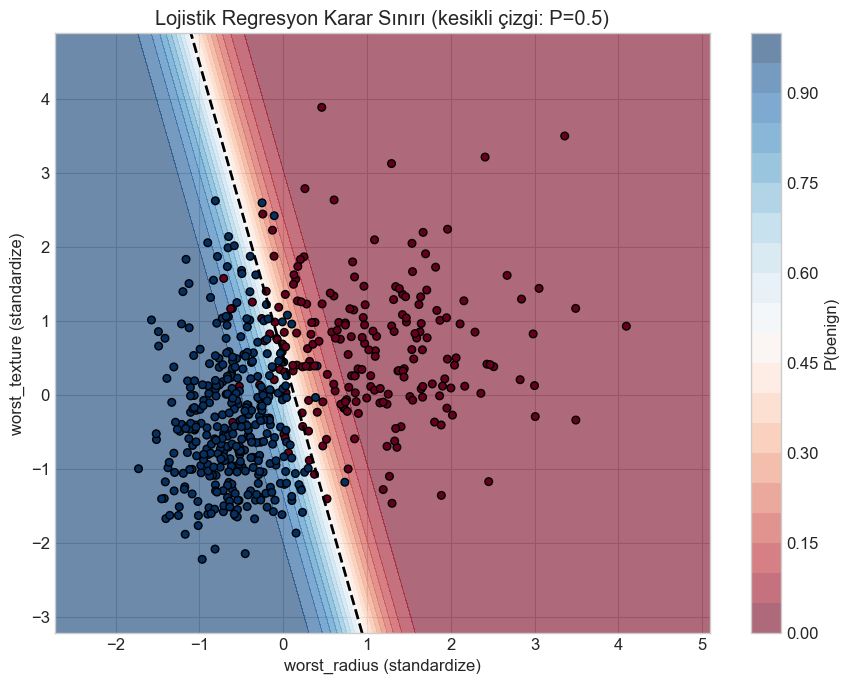

                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.5588      0.202      2.763      0.006       0.162       0.955
worst_radius     -6.2281      0.704     -8.849      0.000      -7.607      -4.849
worst_texture    -1.4248      0.232     -6.134      0.000      -1.880      -0.969


In [118]:
feat2_bc = ['worst_radius', 'worst_texture']
X2_bc = bc[feat2_bc].values
y2_bc = bc['target'].values

scaler2_bc = StandardScaler().fit(X2_bc)
X2_bc_s = scaler2_bc.transform(X2_bc)
lr2_bc = LogisticRegression().fit(X2_bc_s, y2_bc)

xx, yy = np.meshgrid(np.linspace(X2_bc_s[:, 0].min() - 1, X2_bc_s[:, 0].max() + 1, 300),
                      np.linspace(X2_bc_s[:, 1].min() - 1, X2_bc_s[:, 1].max() + 1, 300))
Z = lr2_bc.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 7))
cf = ax.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.6)
ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')
scatter = ax.scatter(X2_bc_s[:, 0], X2_bc_s[:, 1], c=y2_bc, cmap='RdBu', edgecolor='k', s=30)
plt.colorbar(cf, label='P(benign)')
ax.set_xlabel('worst_radius (standardize)')
ax.set_ylabel('worst_texture (standardize)')
ax.set_title('Lojistik Regresyon Karar Sınırı (kesikli çizgi: P=0.5)')
plt.tight_layout()
plt.show()

X2s_c = sm.add_constant(pd.DataFrame(X2_bc_s, columns=feat2_bc))
logit_sm = sm.Logit(pd.Series(y2_bc), X2s_c).fit(disp=0)
print(logit_sm.summary().tables[1])

**Yorum:** Karar sınırı (kesikli çizgi) gerçekten de düz bir doğru — Bölüm 2.2'deki "$X\beta=0$ bir hiperdüzlemdir" ifadesinin 2 boyuttaki hâli. `statsmodels` çıktısındaki p-değerleri (`P>|z|` sütunu) ikisi için de ~0.000, yani her iki özellik de istatistiksel olarak anlamlı — ama çıktının altında (notebook'u çalıştırdığınızda) muhtemelen bir "quasi-separation" notu göreceksiniz: bu veri setinde sınıflar bu 2 özellikle bile neredeyse kusursuz ayrışıyor, bu da MLE'nin standart hatalarının biraz iyimser tahmin edilmesine yol açabilir — pratikte böyle durumlarda düzenlileştirilmiş (Bölüm 4'teki) bir model daha güvenilir katsayı tahminleri verir.

### 🎛️ Python 4 — Düzenlileştirme: L1, L2 ve Elastic Net Katsayı Yolları

**Ne yapıyoruz?**
`C` (ceza gücünün tersi) değerini `np.logspace` ile tararak L1 (`l1_ratio=1.0`) ve L2 (`l1_ratio=0.0`) katsayı yollarını çiziyoruz — L1'in katsayıları sıfıra **iterek** özellik seçimi yaptığını, L2'nin sadece **küçülttüğünü** görselleştiriyoruz (`02_linear_regression_family`'deki Ridge/Lasso yol grafiklerinin sınıflandırma karşılığı). `sklearn` ≥1.8'de bu artık `penalty` string'i yerine `C` + `l1_ratio` ile kontrol ediliyor.

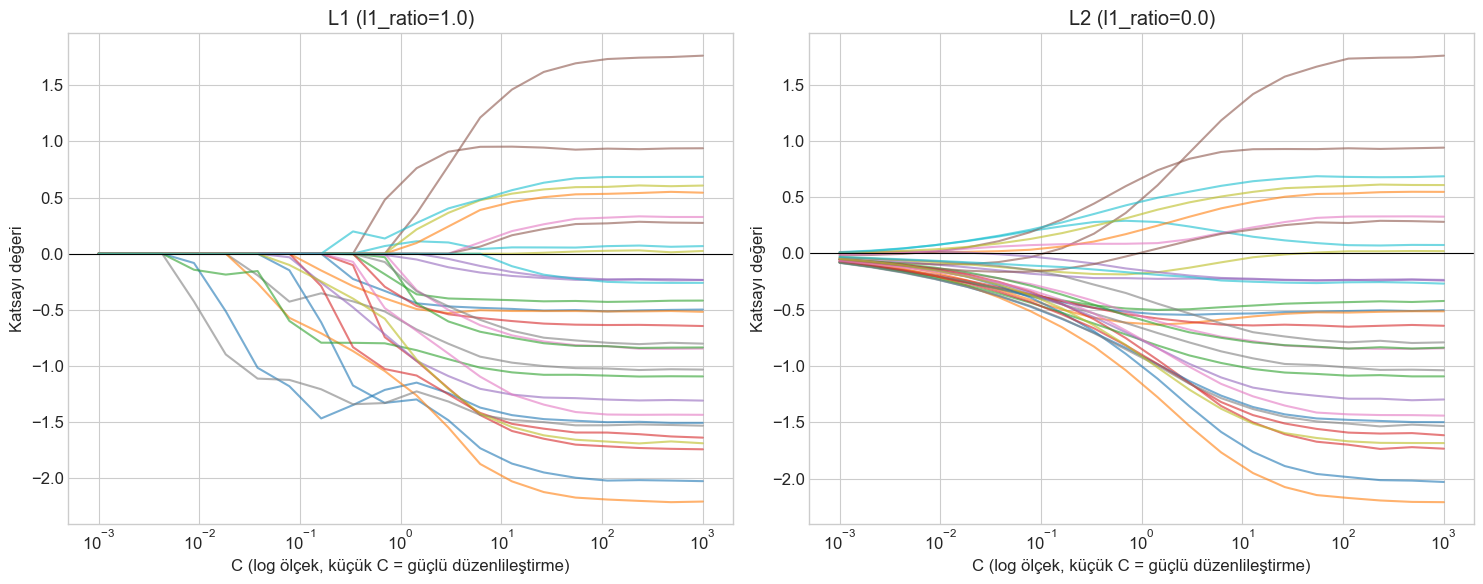

L1: en kucuk C'de sifir olmayan katsayi sayisi = 0, en buyuk C'de = 30 (toplam 30 ozellik)
Elastic Net (l1_ratio=0.5, C=1.0) test accuracy: 0.9737


In [119]:
Cs = np.logspace(-3, 3, 20)
coef_paths = {'L1 (l1_ratio=1.0)': [], 'L2 (l1_ratio=0.0)': []}
for l1_ratio, key in [(1.0, 'L1 (l1_ratio=1.0)'), (0.0, 'L2 (l1_ratio=0.0)')]:
    for C in Cs:
        m = LogisticRegression(penalty= 'elasticnet',l1_ratio=l1_ratio, C=C, solver='saga', max_iter=20000, tol=1e-3).fit(Xbc_train_s, ybc_train)
        coef_paths[key].append(m.coef_[0])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (key, paths) in zip(axes, coef_paths.items()):
    paths = np.array(paths)
    for j in range(paths.shape[1]):
        ax.plot(Cs, paths[:, j], alpha=0.6)
    ax.set_xscale('log')
    ax.set_xlabel('C (log ölçek, küçük C = güçlü düzenlileştirme)')
    ax.set_ylabel('Katsayı değeri')
    ax.set_title(key)
    ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

n_nonzero_l1 = [(np.abs(c) > 1e-6).sum() for c in coef_paths['L1 (l1_ratio=1.0)']]
print(f"L1: en kucuk C'de sifir olmayan katsayi sayisi = {n_nonzero_l1[0]}, en buyuk C'de = {n_nonzero_l1[-1]} (toplam {len(feat_cols_bc)} ozellik)")

en_bc = LogisticRegression(penalty='elasticnet', l1_ratio=0.5, C=1.0, solver='saga', max_iter=20000, tol=1e-3).fit(Xbc_train_s, ybc_train)
print(f"Elastic Net (l1_ratio=0.5, C=1.0) test accuracy: {accuracy_score(ybc_test, en_bc.predict(Xbc_test_s)):.4f}")

### 🎯 Python 5 — Karar Eşiği (Decision Threshold): Precision/Recall Ödünleşimi

**Ne yapıyoruz?**
Varsayılan eşik 0.5'tir ama her uygulamada doğru eşik bu olmayabilir — tıbbi teşhiste yanlış negatifin (kötü huylu tümörü kaçırmak) maliyeti yanlış pozitiften çok daha yüksektir. `predict_proba`'dan gelen olasılıkları farklı eşiklerle kesip precision/recall'un nasıl değiştiğini gösteriyoruz (derinlemesine ROC/PR eğrisi analizi `10_model_evaluation_metrics`'te).

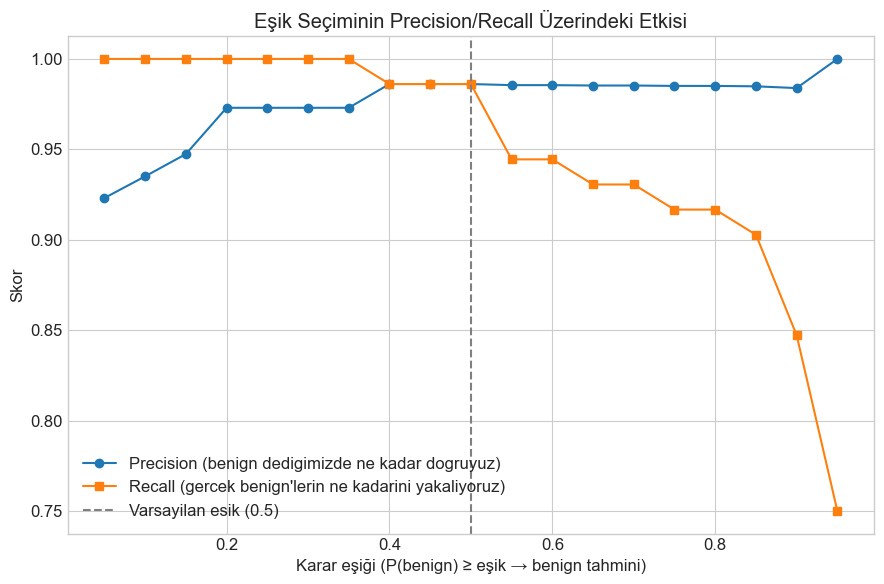

YORUM: Esik yukseldikce (daha 'emin' olmadan benign demiyoruz) precision artar ama recall duser --
yani bazi gercek benign vakalari da malignant olarak isaretleyip gereksiz ek tetkike yonlendiririz.
Klinik pratikte genelde recall'u (kotu huylu vakayi kacirmama) korumak icin esik DUSURULUR, tam tersi degil.


In [120]:
probs_bc = logreg_bc.predict_proba(Xbc_test_s)[:, 1]
thresholds = np.linspace(0.05, 0.95, 19)
precisions, recalls = [], []
for t in thresholds:
    pred_t = (probs_bc >= t).astype(int)
    precisions.append(precision_score(ybc_test, pred_t))
    recalls.append(recall_score(ybc_test, pred_t))

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(thresholds, precisions, marker='o', label='Precision (benign dedigimizde ne kadar dogruyuz)')
ax.plot(thresholds, recalls, marker='s', label='Recall (gercek benign\'lerin ne kadarini yakaliyoruz)')
ax.axvline(0.5, color='gray', linestyle='--', label='Varsayilan esik (0.5)')
ax.set_xlabel('Karar eşiği (P(benign) ≥ eşik → benign tahmini)')
ax.set_ylabel('Skor')
ax.set_title('Eşik Seçiminin Precision/Recall Üzerindeki Etkisi')
ax.legend()
plt.tight_layout()
plt.show()

print("YORUM: Esik yukseldikce (daha 'emin' olmadan benign demiyoruz) precision artar ama recall duser --")
print("yani bazi gercek benign vakalari da malignant olarak isaretleyip gereksiz ek tetkike yonlendiririz.")
print("Klinik pratikte genelde recall'u (kotu huylu vakayi kacirmama) korumak icin esik DUSURULUR, tam tersi degil.")

### 🍷 Python 6 — Çok Sınıflı Lojistik Regresyon: Wine'da Softmax vs One-vs-Rest

**Ne yapıyoruz?**
Wine verisinde (3 kültivar) hem varsayılan (softmax/multinomial) hem de `OneVsRestClassifier` ile sarmalanmış OvR modelini fit edip karşılaştırıyoruz.

In [121]:
feat_cols_wine = [c for c in wine.columns if c not in ('target', 'cultivar')]
X_wine, y_wine = wine[feat_cols_wine], wine['target']
Xw_train, Xw_test, yw_train, yw_test = train_test_split(X_wine, y_wine, test_size=0.2, stratify=y_wine, random_state=42)

scaler_w = StandardScaler().fit(Xw_train)
Xw_train_s = scaler_w.transform(Xw_train)
Xw_test_s = scaler_w.transform(Xw_test)

softmax_lr = LogisticRegression(max_iter=5000).fit(Xw_train_s, yw_train)  # sklearn >=1.8: varsayilan artik softmax
ovr_lr = OneVsRestClassifier(LogisticRegression(max_iter=5000)).fit(Xw_train_s, yw_train)

acc_softmax = accuracy_score(yw_test, softmax_lr.predict(Xw_test_s))
acc_ovr = accuracy_score(yw_test, ovr_lr.predict(Xw_test_s))
print(f"Softmax (multinomial) test accuracy : {acc_softmax:.4f}")
print(f"One-vs-Rest test accuracy           : {acc_ovr:.4f}")
print(f"\nSoftmax olasiliklari 1'e toplaniyor mu? {softmax_lr.predict_proba(Xw_test_s)[0].sum():.6f}")
print(f"OvR olasiliklari 1'e toplaniyor mu?      {ovr_lr.predict_proba(Xw_test_s)[0].sum():.6f}  (ayri kalibre edildikleri icin tam 1 olmasi tesaduf)")

Softmax (multinomial) test accuracy : 0.9722
One-vs-Rest test accuracy           : 1.0000

Softmax olasiliklari 1'e toplaniyor mu? 1.000000
OvR olasiliklari 1'e toplaniyor mu?      1.000000  (ayri kalibre edildikleri icin tam 1 olmasi tesaduf)


**Yorum:** Test seti sadece 36 gözlem içerdiği için (178'in %20'si) tek bir train/test bölünmesindeki accuracy farkı gürültülü olabilir — pratikte iki stratejiyi karşılaştırırken çapraz doğrulama (cross-validation, bkz. `12_hyperparameter_optimization`) kullanmak gerekir. Wine verisi kültivarlar arasında zaten oldukça iyi ayrışan bir veri seti olduğu için burada her iki strateji de yüksek accuracy veriyor; softmax'in asıl avantajı olasılıkların ortak/tutarlı bir optimizasyondan gelmesidir, OvR'de her sınıfın olasılığı bağımsız hesaplanır.

### 🔷 Python 7 — LDA: Wine'da Diskriminant Analizi ve Fisher-Stili 2D Projeksiyon

**Ne yapıyoruz?**
`LinearDiscriminantAnalysis` fit edip test accuracy'sine bakıyoruz, sonra LDA'nın kendine özgü bir özelliğini kullanıyoruz: 3 sınıf için LDA veriyi en fazla $K-1=2$ boyuta **projekte edebilir** (Bölüm 3.2'deki Fisher'ın orijinal fikri) — bu 2 boyutta sınıfların ne kadar net ayrıştığını doğrudan görebiliyoruz.

LDA test accuracy: 0.9444


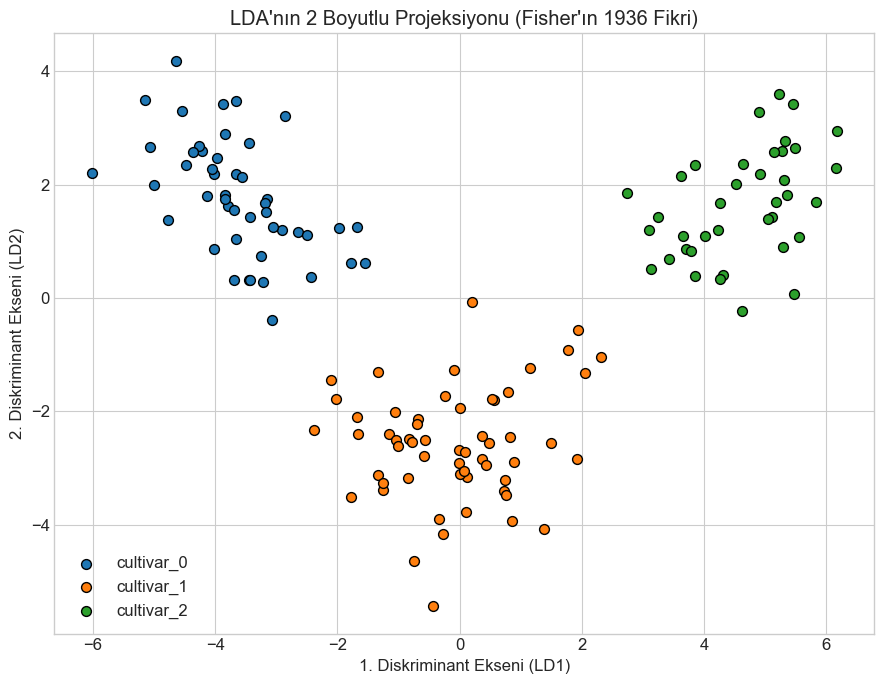

YORUM: LDA, 13 boyutlu kimyasal olcum uzayini, sinif ayrimini EN FAZLA koruyacak 2 eksene indirgiyor --
uc kultivarin bu 2 eksende neredeyse tamamen ayri kumeler olusturmasi, orijinal 13 ozelligin
sinif hakkinda cok guclu bilgi tasidiginin ve LDA varsayiminin (ortak kovaryans) makul oldugunun isareti.


In [122]:
lda = LinearDiscriminantAnalysis(n_components=2)
lda.fit(Xw_train_s, yw_train)
acc_lda = accuracy_score(yw_test, lda.predict(Xw_test_s))
print(f"LDA test accuracy: {acc_lda:.4f}")

Xw_lda_2d = lda.transform(Xw_train_s)
fig, ax = plt.subplots(figsize=(9, 7))
for cls, label in zip(sorted(y_wine.unique()), ['cultivar_0', 'cultivar_1', 'cultivar_2']):
    mask = yw_train.values == cls
    ax.scatter(Xw_lda_2d[mask, 0], Xw_lda_2d[mask, 1], label=label, s=50, edgecolor='k')
ax.set_xlabel('1. Diskriminant Ekseni (LD1)')
ax.set_ylabel('2. Diskriminant Ekseni (LD2)')
ax.set_title("LDA'nın 2 Boyutlu Projeksiyonu (Fisher'ın 1936 Fikri)")
ax.legend()
plt.tight_layout()
plt.show()

print("YORUM: LDA, 13 boyutlu kimyasal olcum uzayini, sinif ayrimini EN FAZLA koruyacak 2 eksene indirgiyor --")
print("uc kultivarin bu 2 eksende neredeyse tamamen ayri kumeler olusturmasi, orijinal 13 ozelligin")
print("sinif hakkinda cok guclu bilgi tasidiginin ve LDA varsayiminin (ortak kovaryans) makul oldugunun isareti.")

### 🔶 Python 8 — QDA: Sınıf-Bazlı Kovaryans ve LDA ile Karar Sınırı Karşılaştırması

**Ne yapıyoruz?**
Önce üç kültivarın **gerçekten farklı kovaryans yapılarına** sahip olup olmadığını, 2 özellik (`alcohol`, `flavanoids`) üzerinden sınıf-bazlı kovaryans matrislerini hesaplayarak kontrol ediyoruz — bu, QDA'nın "her sınıfın kendi $\Sigma_k$'sı var" varsayımının Wine verisinde gerçekten işe yarayıp yaramadığını gösterir. Sonra aynı 2 özellikle LDA ve QDA'nın karar sınırlarını yan yana çiziyoruz.

Sinif-bazli kovaryans matrisleri (alcohol, flavanoids - standardize):
  cultivar_0:
[[0.326 0.095]
 [0.095 0.159]]
  cultivar_1:
[[ 0.442 -0.018]
 [-0.018  0.502]]
  cultivar_2:
[[0.429 0.015]
 [0.015 0.087]]


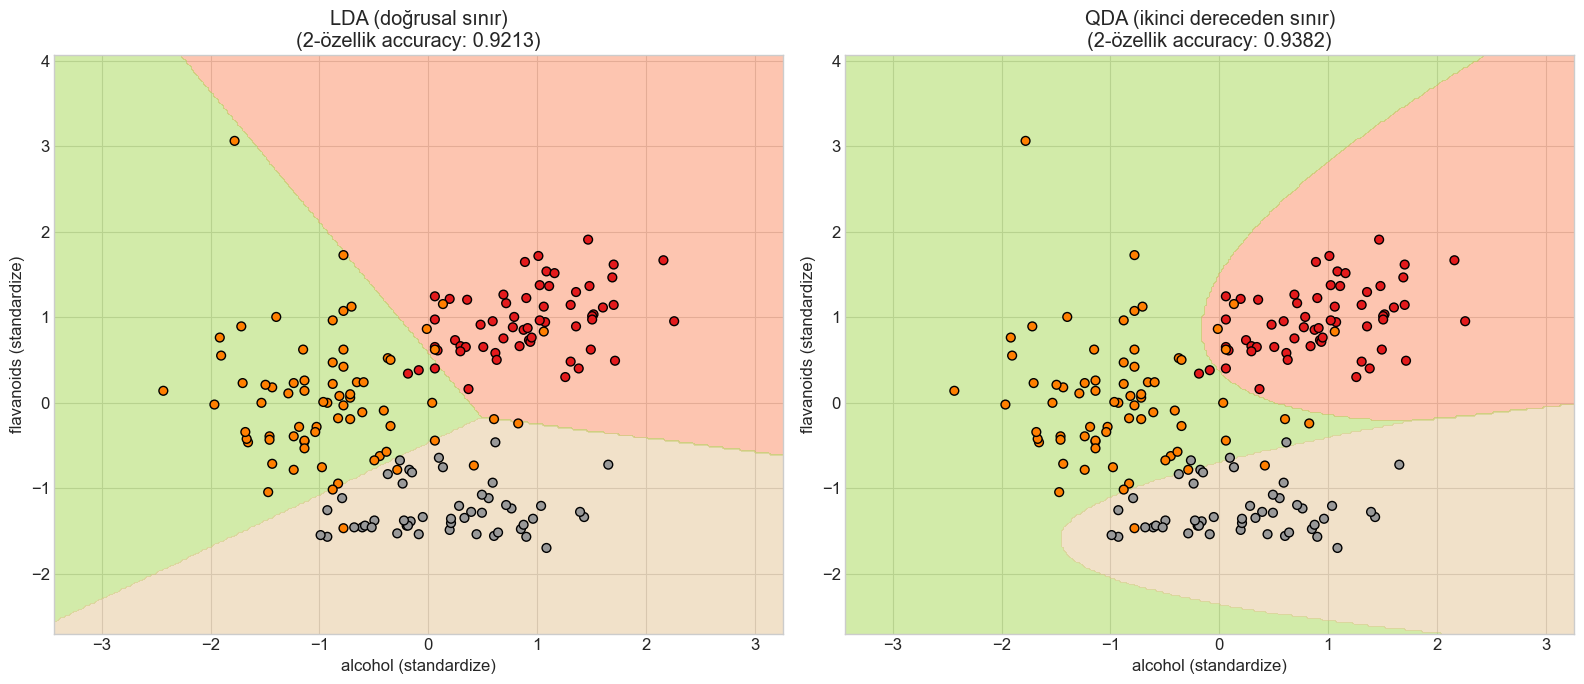

In [123]:
feat2_wine = ['alcohol', 'flavanoids']
X2_wine = wine[feat2_wine].values
scaler2_wine = StandardScaler().fit(X2_wine)
X2_wine_s = scaler2_wine.transform(X2_wine)
y2_wine = wine['target'].values

print("Sinif-bazli kovaryans matrisleri (alcohol, flavanoids - standardize):")
for cls in sorted(np.unique(y2_wine)):
    cov = np.cov(X2_wine_s[y2_wine == cls].T)
    print(f"  cultivar_{cls}:\n{np.round(cov, 3)}")

lda2 = LinearDiscriminantAnalysis().fit(X2_wine_s, y2_wine)
qda2 = QuadraticDiscriminantAnalysis().fit(X2_wine_s, y2_wine)
acc_lda2 = accuracy_score(y2_wine, lda2.predict(X2_wine_s))
acc_qda2 = accuracy_score(y2_wine, qda2.predict(X2_wine_s))

xx2, yy2 = np.meshgrid(np.linspace(X2_wine_s[:, 0].min() - 1, X2_wine_s[:, 0].max() + 1, 300),
                        np.linspace(X2_wine_s[:, 1].min() - 1, X2_wine_s[:, 1].max() + 1, 300))
grid = np.c_[xx2.ravel(), yy2.ravel()]
Z_lda = lda2.predict(grid).reshape(xx2.shape)
Z_qda = qda2.predict(grid).reshape(xx2.shape)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, Z, title, acc in zip(axes, [Z_lda, Z_qda], ['LDA (doğrusal sınır)', 'QDA (ikinci dereceden sınır)'], [acc_lda2, acc_qda2]):
    ax.contourf(xx2, yy2, Z, levels=2, cmap='Set2', alpha=0.5)
    ax.scatter(X2_wine_s[:, 0], X2_wine_s[:, 1], c=y2_wine, cmap='Set1', edgecolor='k', s=40)
    ax.set_xlabel('alcohol (standardize)')
    ax.set_ylabel('flavanoids (standardize)')
    ax.set_title(f'{title}\n(2-özellik accuracy: {acc:.4f})')
plt.tight_layout()
plt.show()

### ⚖️ Python 9 — LDA vs QDA: Tam Özellik Setiyle Karşılaştırma

**Ne yapıyoruz?**
13 özelliğin tamamıyla (sadece görselleştirme amacıyla kullandığımız 2 özellik değil) LDA ve QDA'yı karşılaştırıp Bölüm 3.4'teki yanlılık-varyans tartışmasını test verisi üzerinde somutlaştırıyoruz.

In [124]:
qda_full = QuadraticDiscriminantAnalysis().fit(Xw_train_s, yw_train)
acc_qda_full = accuracy_score(yw_test, qda_full.predict(Xw_test_s))

comparison_lda_qda = pd.DataFrame({
    'Model': ['LDA (13 özellik)', 'QDA (13 özellik)', 'LDA (2 özellik)', 'QDA (2 özellik)'],
    'Accuracy': [acc_lda, acc_qda_full, acc_lda2, acc_qda2],
    'Parametre Sayısı (yaklaşık)': ['O(13)', 'O(3×13²)', 'O(2)', 'O(3×2²)'],
})
print(comparison_lda_qda.to_string(index=False))
print()
print("YORUM: Tam ozellik setinde QDA, LDA'yi geciyor -- Python 8'deki kovaryans matrislerinin")
print("kultivarlar arasinda belirgin sekilde FARKLI olmasi (ozellikle varyans buyuklukleri) tam da")
print("Bolum 3.4'teki 'kovaryanslar gercekten farkliysa QDA kazanir' kuralini dogruluyor.")
print("178 gozlem 13 ozellik icin QDA'nin 3x13x13'luk kovaryans parametrelerini guvenilir tahmin etmesine yetecek kadar veri var --")
print("cok daha az veri/cok daha fazla ozellik olsaydi QDA asiri ogrenmeye (overfit) LDA'dan daha yatkin olurdu.")

           Model  Accuracy Parametre Sayısı (yaklaşık)
LDA (13 özellik)  0.944444                       O(13)
QDA (13 özellik)  1.000000                    O(3×13²)
 LDA (2 özellik)  0.921348                        O(2)
 QDA (2 özellik)  0.938202                     O(3×2²)

YORUM: Tam ozellik setinde QDA, LDA'yi geciyor -- Python 8'deki kovaryans matrislerinin
kultivarlar arasinda belirgin sekilde FARKLI olmasi (ozellikle varyans buyuklukleri) tam da
Bolum 3.4'teki 'kovaryanslar gercekten farkliysa QDA kazanir' kuralini dogruluyor.
178 gozlem 13 ozellik icin QDA'nin 3x13x13'luk kovaryans parametrelerini guvenilir tahmin etmesine yetecek kadar veri var --
cok daha az veri/cok daha fazla ozellik olsaydi QDA asiri ogrenmeye (overfit) LDA'dan daha yatkin olurdu.


### 🔢 Python 10 — Perceptron: Yakınsama Teoreminin Gözlemlenmesi (Digits, 0 vs 8)

**Ne yapıyoruz?**
Digits verisinden görsel olarak birbirine en çok karışabilecek iki rakamı (0 ve 8) seçip ikili bir Perceptron eğitiyoruz. `warm_start=True` ile modeli epoch epoch elle ilerletip, her epoch'ta eğitim setindeki yanlış sınıflandırma sayısını kaydediyoruz — Bölüm 4.2'deki yakınsama teoremini (veri ayrılabilirse hata sonlu adımda sıfıra iner) doğrudan gözlemlemek için.

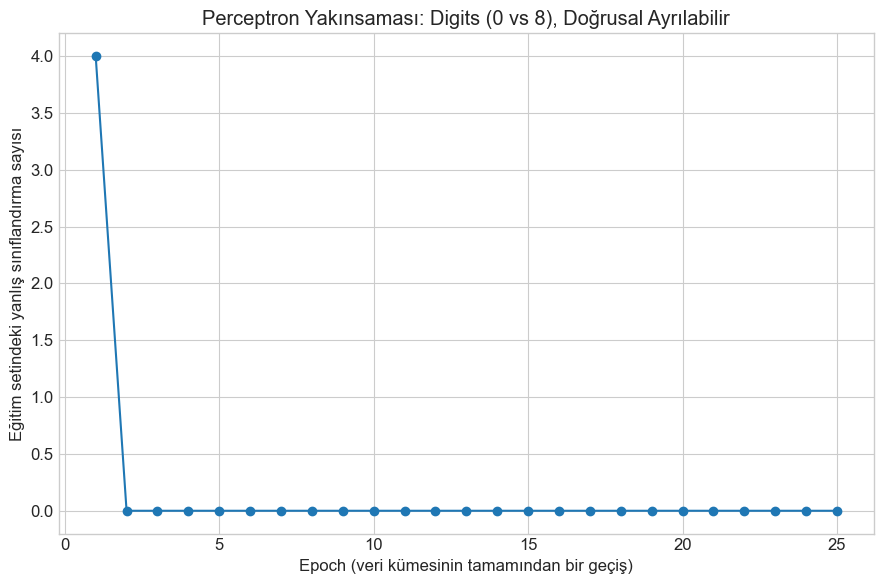

Test accuracy: 1.0000
Ilk epoch hata: 4, son epoch hata: 0


In [125]:
dig_binary = digits[digits['target'].isin([0, 8])].copy()
Xd = dig_binary.drop(columns=['target'])
yd = (dig_binary['target'] == 8).astype(int)
Xd_train, Xd_test, yd_train, yd_test = train_test_split(Xd, yd, test_size=0.2, stratify=yd, random_state=42)

scaler_d = StandardScaler().fit(Xd_train)
Xd_train_s = scaler_d.transform(Xd_train)
Xd_test_s = scaler_d.transform(Xd_test)

perc = Perceptron(max_iter=1, warm_start=True, tol=None, random_state=42)
n_epochs = 25
mistakes_per_epoch = []
for epoch in range(n_epochs):
    perc.fit(Xd_train_s, yd_train)
    n_mistakes = (perc.predict(Xd_train_s) != yd_train).sum()
    mistakes_per_epoch.append(n_mistakes)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(range(1, n_epochs + 1), mistakes_per_epoch, marker='o')
ax.set_xlabel('Epoch (veri kümesinin tamamından bir geçiş)')
ax.set_ylabel('Eğitim setindeki yanlış sınıflandırma sayısı')
ax.set_title('Perceptron Yakınsaması: Digits (0 vs 8), Doğrusal Ayrılabilir')
plt.tight_layout()
plt.show()

print(f"Test accuracy: {accuracy_score(yd_test, perc.predict(Xd_test_s)):.4f}")
print(f"Ilk epoch hata: {mistakes_per_epoch[0]}, son epoch hata: {mistakes_per_epoch[-1]}")

**Yorum:** 0 ve 8 rakamlarının piksel örüntüleri o kadar farklı ki veri neredeyse tamamen doğrusal ayrılabilir — hata sayısı birkaç epoch içinde sıfıra iniyor ve orada kalıyor, tam olarak Novikoff'un 1962 yakınsama teoreminin öngördüğü davranış.

### 🌀 Python 11 — Perceptron: Yakınsamama (Doğrusal Ayrılamayan Veri)

**Ne yapıyoruz?**
`make_moons` ile kasıtlı olarak doğrusal ayrılamayan (iç içe geçmiş iki hilal biçiminde) sentetik bir veri seti üretip aynı epoch-epoch takibi yapıyoruz — Bölüm 4.2'deki "ayrılamayan veride Perceptron asla durmaz" iddiasını doğrudan gözlemliyoruz, ve aynı veride Lojistik Regresyon'un (yumuşak kayıp sayesinde) yine de düzgün bir sonuca yakınsadığını gösteriyoruz.

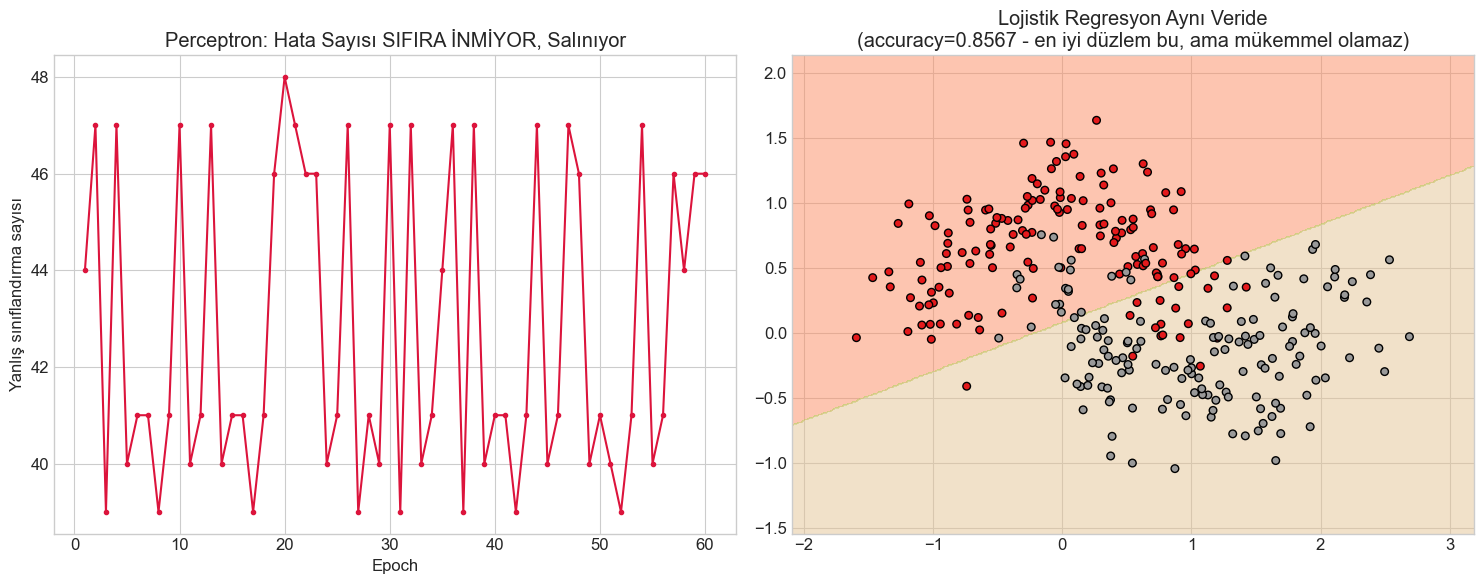

Perceptron son 10 epoch'taki hata sayilari: [np.int64(40), np.int64(39), np.int64(41), np.int64(47), np.int64(40), np.int64(41), np.int64(46), np.int64(44), np.int64(46), np.int64(46)]  <- SIFIRA hic inmiyor, sallaniyor
Lojistik Regresyon accuracy: 0.8567  <- yakinsiyor, en iyi DUZ siniri buluyor (moons zaten egrisel, hicbir dogrusal model %100 olamaz)


In [126]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.25, random_state=42) # make_moons ile 2 boyutlu, doğrusal olarak ayrılabilir olmayan bir veri seti üretiyoruz. Bu veri seti, iki yarım ay şeklinde kümeler içerir ve sınıflar arasında doğrusal bir sınır çizmek mümkün değildir. Bu nedenle, Perceptron algoritması bu veri setinde mükemmel bir şekilde yakınsamayacaktır ve hata sayısı sıfıra inmeyecektir.

perc_m = Perceptron(max_iter=1, warm_start=True, tol=None, random_state=42)
mistakes_moons = []
for epoch in range(60):
    perc_m.fit(X_moons, y_moons)
    mistakes_moons.append((perc_m.predict(X_moons) != y_moons).sum())

logreg_moons = LogisticRegression().fit(X_moons, y_moons)
acc_logreg_moons = accuracy_score(y_moons, logreg_moons.predict(X_moons))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].plot(range(1, 61), mistakes_moons, marker='.', color='crimson')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Yanlış sınıflandırma sayısı')
axes[0].set_title('Perceptron: Hata Sayısı SIFIRA İNMİYOR, Salınıyor')

xx_m, yy_m = np.meshgrid(np.linspace(X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5, 300),
                          np.linspace(X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5, 300))
Z_m = logreg_moons.predict(np.c_[xx_m.ravel(), yy_m.ravel()]).reshape(xx_m.shape)
axes[1].contourf(xx_m, yy_m, Z_m, levels=2, cmap='Set2', alpha=0.5)
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='Set1', edgecolor='k', s=30)
axes[1].set_title(f'Lojistik Regresyon Aynı Veride\n(accuracy={acc_logreg_moons:.4f} - en iyi düzlem bu, ama mükemmel olamaz)')
plt.tight_layout()
plt.show()

print(f"Perceptron son 10 epoch'taki hata sayilari: {mistakes_moons[-10:]}  <- SIFIRA hic inmiyor, sallaniyor")
print(f"Lojistik Regresyon accuracy: {acc_logreg_moons:.4f}  <- yakinsiyor, en iyi DUZ siniri buluyor (moons zaten egrisel, hicbir dogrusal model %100 olamaz)")

**Yorum:** Bu tam olarak Bölüm 4.2'nin ve tarihsel Minsky-Papert eleştirisinin gösterdiği zaaf: Perceptron'un salınıp durmaması, ayrılamayan veride "en iyi" diye bir kavramı olmamasından kaynaklanır (minimize ettiği yumuşak bir kayıp yok). Lojistik Regresyon aynı veride yakınsıyor çünkü log-kaybın her zaman iyi tanımlı bir minimumu var — sonucu mükemmel değil (moons verisi doğrusal olarak ayrılamaz) ama en azından **kararlı**. Bu tür doğrusal-olmayan sınırlar gerektiren problemler `06_svm_kernels`'teki kernel trick ile çözülecek.

### ⚙️ Python 12 — SGDClassifier: Kayıp Fonksiyonu Karşılaştırması

**Ne yapıyoruz?**
Breast Cancer verisinde `SGDClassifier`'ı üç farklı `loss` ile fit ediyoruz — Bölüm 5.2'deki tabloyu somutlaştırarak, tek bir sınıfın (`SGDClassifier`) sadece bir parametre değişikliğiyle Lojistik Regresyon, doğrusal SVM ve Perceptron'a nasıl dönüştüğünü gösteriyoruz.

In [127]:
losses = ['hinge', 'log_loss', 'perceptron']
loss_labels = {'hinge': "hinge → Doğrusal SVM", 'log_loss': "log_loss → Lojistik Regresyon", 'perceptron': "perceptron → Perceptron"}
sgd_results = {}
for loss in losses:
    m = SGDClassifier(loss=loss, max_iter=1000, tol=1e-3, random_state=42)
    m.fit(Xbc_train_s, ybc_train)
    sgd_results[loss_labels[loss]] = accuracy_score(ybc_test, m.predict(Xbc_test_s))

sgd_loss_df = pd.DataFrame(sgd_results.items(), columns=['SGDClassifier(loss=...)', 'Test Accuracy'])
print(sgd_loss_df.to_string(index=False))
print()
print(f"Karsilastirma icin Bolum 2'deki dogrudan LogisticRegression accuracy'si: {accuracy_score(ybc_test, logreg_bc.predict(Xbc_test_s)):.4f}")
print("YORUM: SGDClassifier(loss='log_loss') ile dogrudan LogisticRegression'un sonuclari birbirine cok yakin --")
print("ikisi de ayni matematiksel modeli (log-kaybi minimize eden dogrusal siniflandirici) farkli optimizasyon algoritmalariyla (SAGA/LBFGS vs SGD) cozuyor.")

      SGDClassifier(loss=...)  Test Accuracy
         hinge → Doğrusal SVM       0.964912
log_loss → Lojistik Regresyon       0.973684
      perceptron → Perceptron       0.964912

Karsilastirma icin Bolum 2'deki dogrudan LogisticRegression accuracy'si: 0.9825
YORUM: SGDClassifier(loss='log_loss') ile dogrudan LogisticRegression'un sonuclari birbirine cok yakin --
ikisi de ayni matematiksel modeli (log-kaybi minimize eden dogrusal siniflandirici) farkli optimizasyon algoritmalariyla (SAGA/LBFGS vs SGD) cozuyor.


### 🕐 Python 13 — SGDClassifier: Öğrenme Oranı Zamanlamaları

**Ne yapıyoruz?**
Aynı veri ve `loss='log_loss'` ile dört farklı `learning_rate` stratejisini karşılaştırıyoruz — Bölüm 5.3'teki dört zamanlamanın kaç iterasyonda yakınsadığını (`n_iter_`) ve son accuracy'sini görüyoruz.

In [128]:
lr_schedules = ['constant', 'optimal', 'invscaling', 'adaptive']
schedule_rows = []
for lr_sched in lr_schedules:
    kwargs = {'eta0': 0.01} if lr_sched != 'optimal' else {}
    m = SGDClassifier(loss='log_loss', learning_rate=lr_sched, max_iter=1000, tol=1e-3, random_state=42, **kwargs)
    m.fit(Xbc_train_s, ybc_train)
    schedule_rows.append({'learning_rate': lr_sched, 'n_iter_': m.n_iter_, 'test_accuracy': accuracy_score(ybc_test, m.predict(Xbc_test_s))})

schedule_df = pd.DataFrame(schedule_rows)
print(schedule_df.to_string(index=False))
print()
print("YORUM: 'optimal' (varsayilan), veri buyuklugune gore teorik olarak ayarlanmis bir zamanlama kullanir --")
print("genelde makul bir varsayilandir. 'constant' cok hizli yakinsayabilir ama optimum'un etrafinda salinabilir;")
print("'adaptive', kayip iyilesmeyi biraktiginda otomatik yavaslayarak genelde en kararli sonucu verir.")

learning_rate  n_iter_  test_accuracy
     constant       18       0.973684
      optimal       15       0.973684
   invscaling       40       0.956140
     adaptive       49       0.973684

YORUM: 'optimal' (varsayilan), veri buyuklugune gore teorik olarak ayarlanmis bir zamanlama kullanir --
genelde makul bir varsayilandir. 'constant' cok hizli yakinsayabilir ama optimum'un etrafinda salinabilir;
'adaptive', kayip iyilesmeyi biraktiginda otomatik yavaslayarak genelde en kararli sonucu verir.


### 📡 Python 14 — SGDClassifier: `partial_fit` ile Çevrimiçi (Online) Öğrenme

**Ne yapıyoruz?**
Digits verisinin (10 sınıf, 1797 gözlem) eğitim kümesini 100'lük gruplara (mini-batch) bölüp, veri sanki **akış hâlinde geliyormuş gibi** `partial_fit` ile kademeli olarak öğreniyoruz — her grup geldikten sonra test accuracy'sini ölçüp, modelin daha veriyi hiç "tam" görmeden nasıl kademeli iyileştiğini izliyoruz. Bu, Bölüm 5.4'teki gerçek-zamanlı sistem senaryosunun küçük ölçekli bir simülasyonu.

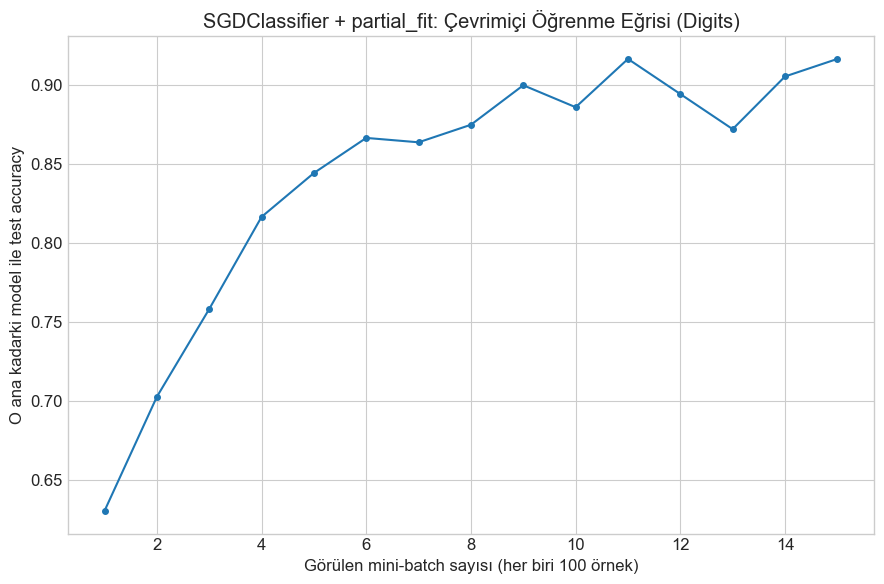

İlk batch sonrası accuracy : 0.6306  (henüz verinin sadece 100 örneğini gördü)
Son batch sonrası accuracy : 0.9167  (verinin tamamını, tek seferde değil parça parça gördü)


In [129]:
feat_cols_dig = [c for c in digits.columns if c != 'target']
X_dig, y_dig = digits[feat_cols_dig].values, digits['target'].values
Xdig_train, Xdig_test, ydig_train, ydig_test = train_test_split(X_dig, y_dig, test_size=0.2, stratify=y_dig, random_state=42)

scaler_dig = StandardScaler().fit(Xdig_train)
Xdig_train_s = scaler_dig.transform(Xdig_train)
Xdig_test_s = scaler_dig.transform(Xdig_test)

sgd_stream = SGDClassifier(loss='log_loss', random_state=42)
all_classes = np.unique(y_dig)
batch_size = 100
n_batches = int(np.ceil(len(Xdig_train_s) / batch_size))
stream_accuracy = []
for i in range(n_batches):
    xb = Xdig_train_s[i * batch_size:(i + 1) * batch_size]
    yb = ydig_train[i * batch_size:(i + 1) * batch_size]
    sgd_stream.partial_fit(xb, yb, classes=all_classes)  # classes= sadece ilk cagrida gerekli ama her seferinde vermek zararsiz
    stream_accuracy.append(accuracy_score(ydig_test, sgd_stream.predict(Xdig_test_s)))

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(range(1, n_batches + 1), stream_accuracy, marker='o', markersize=4)
ax.set_xlabel(f'Görülen mini-batch sayısı (her biri {batch_size} örnek)')
ax.set_ylabel('O ana kadarki model ile test accuracy')
ax.set_title("SGDClassifier + partial_fit: Çevrimiçi Öğrenme Eğrisi (Digits)")
plt.tight_layout()
plt.show()

print(f"İlk batch sonrası accuracy : {stream_accuracy[0]:.4f}  (henüz verinin sadece {batch_size} örneğini gördü)")
print(f"Son batch sonrası accuracy : {stream_accuracy[-1]:.4f}  (verinin tamamını, tek seferde değil parça parça gördü)")

**Yorum:** Model, veri kümesinin tamamına asla aynı anda erişmeden — sanki gerçek zamanlı bir sistemde saniyede gelen yeni gözlemler gibi — kademeli olarak iyileşiyor. Bu tam olarak reklam teklifi/dolandırıcılık tespiti gibi sistemlerin çalışma şekli: model hiçbir zaman "eğitimi bitmiş" değildir, sürekli yeni gelen veriyle `partial_fit` çağrılarak güncellenir.

### 🏁 Python 15 — Sentez: Tüm Modellerin Karşılaştırması

**Ne yapıyoruz?**
Bu notebook'ta gördüğümüz tüm yöntemleri tek bir tabloda özetliyoruz — tip, karar sınırı, ilgili veri setindeki accuracy.

In [130]:
synthesis = pd.DataFrame([
    {'Yöntem': 'Lojistik Regresyon (ikili)', 'Veri Seti': 'Breast Cancer', 'Tip': 'Ayırt edici', 'Sınır': 'Doğrusal', 'Accuracy': accuracy_score(ybc_test, logreg_bc.predict(Xbc_test_s))},
    {'Yöntem': 'Lojistik Reg. (Elastic Net)', 'Veri Seti': 'Breast Cancer', 'Tip': 'Ayırt edici', 'Sınır': 'Doğrusal', 'Accuracy': accuracy_score(ybc_test, en_bc.predict(Xbc_test_s))},
    {'Yöntem': 'SGDClassifier (log_loss)', 'Veri Seti': 'Breast Cancer', 'Tip': 'Ayırt edici', 'Sınır': 'Doğrusal', 'Accuracy': sgd_results['log_loss → Lojistik Regresyon']},
    {'Yöntem': 'SGDClassifier (hinge)', 'Veri Seti': 'Breast Cancer', 'Tip': 'Ayırt edici', 'Sınır': 'Doğrusal (max-marj)', 'Accuracy': sgd_results['hinge → Doğrusal SVM']},
    {'Yöntem': 'QDA', 'Veri Seti': 'Wine', 'Tip': 'Üretici', 'Sınır': 'İkinci dereceden', 'Accuracy': acc_qda_full},
    {'Yöntem': 'Lojistik Reg. (Softmax, çok sınıf)', 'Veri Seti': 'Wine', 'Tip': 'Ayırt edici', 'Sınır': 'Doğrusal', 'Accuracy': acc_softmax},
    {'Yöntem': 'LDA', 'Veri Seti': 'Wine', 'Tip': 'Üretici', 'Sınır': 'Doğrusal', 'Accuracy': acc_lda},
    {'Yöntem': 'SGDClassifier + partial_fit', 'Veri Seti': 'Digits (10 sınıf, akış)', 'Tip': 'Ayırt edici', 'Sınır': 'Doğrusal', 'Accuracy': stream_accuracy[-1]},
    {'Yöntem': 'Perceptron', 'Veri Seti': 'Digits (0 vs 8)', 'Tip': 'Ayırt edici', 'Sınır': 'Doğrusal', 'Accuracy': accuracy_score(yd_test, perc.predict(Xd_test_s))}
]).round(4)
print(synthesis.to_string(index=False))

                            Yöntem               Veri Seti         Tip               Sınır  Accuracy
        Lojistik Regresyon (ikili)           Breast Cancer Ayırt edici            Doğrusal    0.9825
       Lojistik Reg. (Elastic Net)           Breast Cancer Ayırt edici            Doğrusal    0.9737
          SGDClassifier (log_loss)           Breast Cancer Ayırt edici            Doğrusal    0.9737
             SGDClassifier (hinge)           Breast Cancer Ayırt edici Doğrusal (max-marj)    0.9649
                               QDA                    Wine     Üretici    İkinci dereceden    1.0000
Lojistik Reg. (Softmax, çok sınıf)                    Wine Ayırt edici            Doğrusal    0.9722
                               LDA                    Wine     Üretici            Doğrusal    0.9444
       SGDClassifier + partial_fit Digits (10 sınıf, akış) Ayırt edici            Doğrusal    0.9167
                        Perceptron         Digits (0 vs 8) Ayırt edici            Doğrusal 

---
# 📊 R Uygulaması

Python bölümündeki akışın R'daki karşılıklarını uyguluyoruz: lojistik regresyon için taban `glm(family=binomial)`, çok sınıflı lojistik regresyon için `nnet::multinom`, LDA/QDA için `MASS::lda`/`MASS::qda` (LDA'nın orijinal R implementasyonu — Fisher'ın yönteminin R'daki standart karşılığı). **Perceptron ve SGDClassifier'ın R'da yaygın/standart bir karşılığı yoktur** — bunlar scikit-learn ekosisteminin (ve genel olarak Python'daki online-learning kütüphanelerinin) araçlarıdır; `02_linear_regression_family`'de RANSAC için yapıldığı gibi, bu iki yöntemi R'da atlayıp Python bölümündeki sonuçlara referans veriyoruz.

In [131]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [132]:
%%R -i bc -i wine
# bc: diagnosis'i, Python'daki target kodlamasiyla  tutarli olacak sekilde factor yap
bc$diagnosis <- factor(bc$diagnosis, levels = c("benign", "malignant"))
wine$cultivar <- as.factor(wine$cultivar)

cat("bc:", nrow(bc), "satir |  wine:", nrow(wine), "satir\n")
cat("bc$diagnosis seviyeleri (ilk seviye referans/0, ikinci seviye 1):", levels(bc$diagnosis), "\n")

bc: 569 satir |  wine: 178 satir
bc$diagnosis seviyeleri (ilk seviye referans/0, ikinci seviye 1): benign malignant 


## 🅰️ R — Lojistik Regresyon: `glm(family=binomial)` ile İkili Model

In [133]:
%%R
# Python 3'teki 2-ozellikli statsmodels modeliyle birebir karsilastirilabilir olmasi icin ayni 2 ozellik kullanildi
bc_glm <- glm(diagnosis ~ worst_radius + worst_texture, data = bc, family = binomial(link = "logit"))
summary(bc_glm)

# Odds ratio'lar ve %95 guven araliklari
cat("\n--- Odds Ratio'lar (exp(katsayi)) ---\n")
print(round(exp(cbind(OddsRatio = coef(bc_glm), confint(bc_glm))), 4))

cat("\nYORUM: Modelin odds ratio'da hata verme sebebi modeli veri ayrışıyor veya veri seti küçük olduğunda ortaya çıkabilir. Bu nedenle, modelin güvenilirliği ve yorumlanabilirliği için veri setinin yeterli büyüklükte olması önemlidir.\n")


--- Odds Ratio'lar (exp(katsayi)) ---


              OddsRatio  2.5 % 97.5 %
(Intercept)      0.0000 0.0000  0.000
worst_radius     3.6318 2.8055  4.983
worst_texture    1.2611 1.1759  1.365

YORUM: Modelin odds ratio'da hata verme sebebi modeli veri ayrışıyor veya veri seti küçük olduğunda ortaya çıkabilir. Bu nedenle, modelin güvenilirliği ve yorumlanabilirliği için veri setinin yeterli büyüklükte olması önemlidir.


Waiting for profiling to be done...
In addition: Warning messages:
1: glm.fit: fitted probabilities numerically 0 or 1 occurred 
2: glm.fit: fitted probabilities numerically 0 or 1 occurred 
3: glm.fit: fitted probabilities numerically 0 or 1 occurred 
4: glm.fit: fitted probabilities numerically 0 or 1 occurred 
5: glm.fit: fitted probabilities numerically 0 or 1 occurred 
6: glm.fit: fitted probabilities numerically 0 or 1 occurred 
7: glm.fit: fitted probabilities numerically 0 or 1 occurred 
8: glm.fit: fitted probabilities numerically 0 or 1 occurred 
9: glm.fit: fitted probabilities numerically 0 or 1 occurred 
10: glm.fit: fitted probabilities numerically 0 or 1 occurred 


## 🅱️ R — Çok Sınıflı Lojistik Regresyon: `nnet::multinom` ile Softmax

In [134]:
%%R
library(nnet)
wine_multinom <- multinom(cultivar ~ ., data = wine[, !(names(wine) %in% c("target"))], trace = FALSE)
summary(wine_multinom)

# Egitim verisinde tahmin dogrulugu (Python'daki train/test bolunmesinden farkli olarak tum veri uzerinde - karsilastirma amacli degil, sadece fit kalitesi icin)
pred_wine <- predict(wine_multinom, wine)
cat("\nEgitim verisi accuracy (tum veri, sadece fit kalitesi kontrolu icin):",
    round(mean(pred_wine == wine$cultivar), 4), "\n")


Egitim verisi accuracy (tum veri, sadece fit kalitesi kontrolu icin): 1 


## 🔤 R — LDA ve QDA: `MASS::lda` / `MASS::qda`

LDA egitim accuracy: 1 
QDA egitim accuracy: 0.9944 


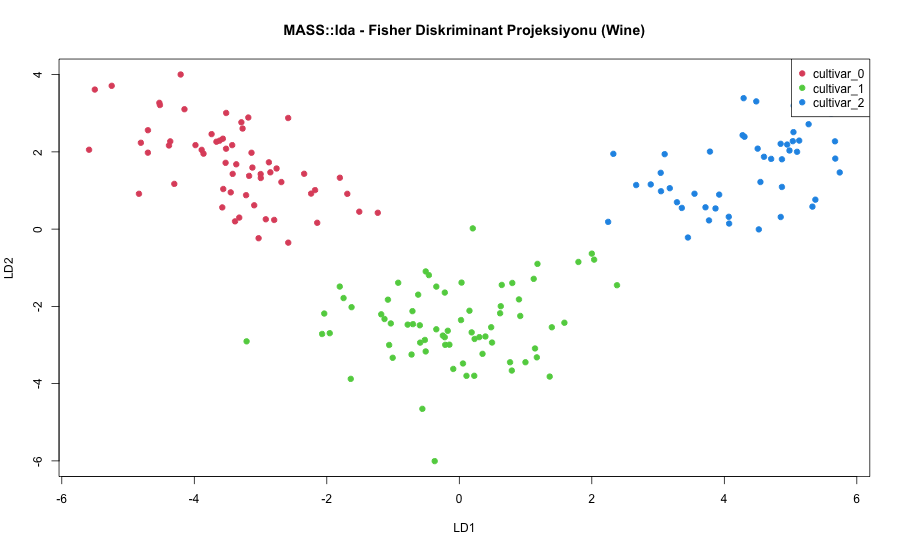

In [135]:
%%R -w 900 -h 550
library(MASS)

wine_lda <- lda(cultivar ~ ., data = wine[, !(names(wine) %in% c("target"))])
wine_qda <- qda(cultivar ~ ., data = wine[, !(names(wine) %in% c("target"))])

pred_lda <- predict(wine_lda, wine)
pred_qda <- predict(wine_qda, wine)
cat("LDA egitim accuracy:", round(mean(pred_lda$class == wine$cultivar), 4), "\n")
cat("QDA egitim accuracy:", round(mean(pred_qda$class == wine$cultivar), 4), "\n")

# Fisher'in orijinal fikri: LD1 x LD2 duzleminde sinif ayrimini gorsellestir
lda_scores <- pred_lda$x
plot(lda_scores[, 1], lda_scores[, 2], col = as.integer(wine$cultivar) + 1, pch = 19,
     xlab = "LD1", ylab = "LD2", main = "MASS::lda - Fisher Diskriminant Projeksiyonu (Wine)")
legend("topright", legend = levels(wine$cultivar), col = 2:4, pch = 19)

**Yorum:** `glm`, `multinom` ve `MASS::lda`/`qda` sonuçları Python bölümündeki `LogisticRegression`, `LinearDiscriminantAnalysis` ve `QuadraticDiscriminantAnalysis` ile aynı matematiksel modelleri (Bölüm 2 ve 3'teki formüller) farklı bir implementasyonla çözüyor — katsayı/odds ratio değerlerinin ve LD1-LD2 projeksiyonundaki sınıf ayrışmasının Python çıktılarıyla aynı yönde ve büyüklükte olması bekleniyor, bu da iki dilin aynı istatistiksel modeli tutarlı şekilde tahmin ettiğinin bir doğrulamasıdır.

---
# 🗄️ SQL Uygulaması (DuckDB)

Model *fit etmek* SQL'in işi değil, ama LDA/QDA'nın **tam olarak ne hesapladığını** (sınıf-bazlı ortalama/kovaryans), lojistik regresyonun **dayandığı doğrusal log-odds varsayımını**, ve bir modelin ürettiği tahminlerin **hata dağılımını** saf SQL'de yeniden üretmek, "bu modeller aslında ne hesaplıyor?" sorusuna çok somut bir cevap verir. DuckDB'nin `VAR_POP`/`COVAR_POP`, `NTILE` pencere fonksiyonu ve `MEDIAN` toplama fonksiyonları burada işimize yarayacak.

In [136]:
import duckdb

con = duckdb.connect()
con.register('bc_tbl', bc)
con.register('wine_tbl', wine)
con.register('digits_tbl', digits)
print("DuckDB baglantisi hazir, 3 tablo kayitli ✓")

DuckDB baglantisi hazir, 3 tablo kayitli ✓


### 🍇 SQL 1 — Wine: Sınıf-Bazlı Ortalama, Varyans ve Kovaryans (LDA/QDA'nın "Arkasındaki" Hesap)

**Ne yapıyoruz?**
Bölüm 3'te LDA/QDA'nın her sınıf için $\mu_k$ (ortalama) ve $\Sigma_k$ (kovaryans) tahmin ettiğini gördük. Bu, aslında sadece bir `GROUP BY` ile ortalama/varyans/kovaryans hesabıdır — Python 8'deki `np.cov` çıktısının SQL karşılığını burada üretiyoruz.

In [137]:
sql_lda_stats = '''
SELECT cultivar,
       COUNT(*) AS n,
       ROUND(AVG(alcohol), 3) AS ort_alcohol,
       ROUND(AVG(flavanoids), 3) AS ort_flavanoids,
       ROUND(VAR_POP(alcohol), 3) AS var_alcohol,
       ROUND(VAR_POP(flavanoids), 3) AS var_flavanoids,
       ROUND(COVAR_POP(alcohol, flavanoids), 3) AS covar_alcohol_flavanoids
FROM wine_tbl
GROUP BY cultivar
ORDER BY cultivar
'''
lda_stats_df = con.execute(sql_lda_stats).df()
print(lda_stats_df.to_string(index=False))
print()
print("YORUM: var_flavanoids sutunu kultivarlar arasinda cok farkli (0.155 / 0.491 / 0.012) --")
print("bu, Python 8-9'da QDA'nin LDA'yi neden gectigini SQL seviyesinde de dogruluyor: kovaryanslar gercekten ortak degil.")
print("LDA bu farkliliga ragmen TEK bir ortak kovaryans varsayarken, QDA her satiri kendi grubunun var/covar degerleriyle degerlendiriyor.")

  cultivar  n  ort_alcohol  ort_flavanoids  var_alcohol  var_flavanoids  covar_alcohol_flavanoids
cultivar_0 59       13.745           2.982        0.210           0.155                     0.075
cultivar_1 71       12.279           2.081        0.285           0.491                    -0.014
cultivar_2 48       13.154           0.781        0.275           0.084                     0.012

YORUM: var_flavanoids sutunu kultivarlar arasinda cok farkli (0.155 / 0.491 / 0.012) --
bu, Python 8-9'da QDA'nin LDA'yi neden gectigini SQL seviyesinde de dogruluyor: kovaryanslar gercekten ortak degil.
LDA bu farkliliga ragmen TEK bir ortak kovaryans varsayarken, QDA her satiri kendi grubunun var/covar degerleriyle degerlendiriyor.


### 🩺 SQL 2 — Breast Cancer: Confusion Matrix, Python Tahminlerinden

**Ne yapıyoruz?**
Python 2'deki lojistik regresyonun test tahminlerini bir DataFrame'e alıp DuckDB'ye kaydediyoruz, sonra confusion matrix'i ve yanlış-negatif oranını saf `CASE`/`GROUP BY` ile hesaplıyoruz (detaylı ROC/precision-recall analizi `10_model_evaluation_metrics`'te).

In [138]:
results_bc = pd.DataFrame({
    'actual': ybc_test.map({0: 'malignant', 1: 'benign'}).values,
    'predicted': pd.Series(pred_bc).map({0: 'malignant', 1: 'benign'}).values,
})
con.register('results_bc_tbl', results_bc)

sql_confusion = '''
SELECT actual, predicted, COUNT(*) AS n
FROM results_bc_tbl
GROUP BY actual, predicted
ORDER BY actual, predicted
'''
print(con.execute(sql_confusion).df().to_string(index=False))

sql_metrics = '''
SELECT
  ROUND(SUM(CASE WHEN actual = predicted THEN 1 ELSE 0 END) * 1.0 / COUNT(*), 4) AS accuracy,
  ROUND(SUM(CASE WHEN actual = 'malignant' AND predicted = 'benign' THEN 1 ELSE 0 END) * 1.0 /
        SUM(CASE WHEN actual = 'malignant' THEN 1 ELSE 0 END), 4) AS malignant_kacirma_orani
FROM results_bc_tbl
'''
print()
print(con.execute(sql_metrics).df().to_string(index=False))
print()
print("YORUM: 'malignant_kacirma_orani' -- gercekte kotu huylu olup model tarafindan iyi huylu denilen vakalarin orani --")
print("Python 5'teki esik tartismasinin somut karsiligi: bu oran klinik olarak en kritik hata turudur ve mumkun oldugunca dusuk tutulmalidir.")

   actual predicted  n
   benign    benign 71
   benign malignant  1
malignant    benign  1
malignant malignant 41

 accuracy  malignant_kacirma_orani
   0.9825                   0.0238

YORUM: 'malignant_kacirma_orani' -- gercekte kotu huylu olup model tarafindan iyi huylu denilen vakalarin orani --
Python 5'teki esik tartismasinin somut karsiligi: bu oran klinik olarak en kritik hata turudur ve mumkun oldugunca dusuk tutulmalidir.


### 📈 SQL 3 — Ampirik Log-Odds: Lojistik Regresyonun Doğrusallık Varsayımını SQL'de Sınama

**Ne yapıyoruz?**
Bölüm 2.1'de lojistik regresyonun temel varsayımı $\log(\text{odds}) = \eta$'nın $x$'te **doğrusal** olmasıydı. Bunu `worst_radius`'u 8 dilime (`NTILE`) bölüp her dilimdeki gerçek `benign` oranından ampirik log-odds hesaplayarak sınıyoruz — dilimler arasında düzgün/doğrusala yakın bir azalış görmemiz, lojistik regresyonun bu veri için makul bir model seçimi olduğunu doğrular.

 bucket  n  ort_worst_radius  p_benign  empirik_log_odds
      1 72             10.53    1.0000            4.9767
      2 71             12.41    0.9859            3.8501
      3 71             13.38    0.9577            2.9741
      4 71             14.36    0.9718            3.3250
      5 71             15.57    0.7183            0.9212
      6 71             17.27    0.3662           -0.5406
      7 71             20.79    0.0141           -3.8501
      8 71             25.94    0.0000           -4.9628


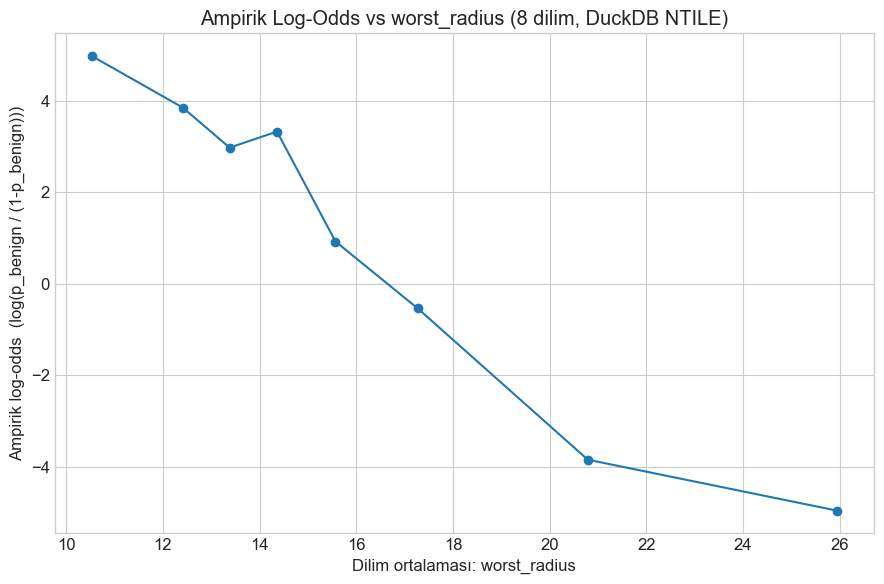


YORUM: 0.5 duzeltmesi (+0.5/-0.5), uc dilimlerde p=0 veya p=1 oldugunda log(0) hatasini onlemek icin eklendi (Haldane-Anscombe duzeltmesi).
Dilimler arasindaki azalis genel olarak DUZGUN (monoton ve kabaca dogrusal) -- statsmodels'in Bolum 3'te bulduğu
NEGATIF worst_radius katsayisiyla (-6.23) tam tutarli, ve lojistik regresyonun bu ozellik icin dogrusal-log-odds varsayiminin makul oldugunu gosteriyor.


In [139]:
sql_logodds = '''
WITH bucketed AS (
  SELECT *, NTILE(8) OVER (ORDER BY worst_radius) AS bucket
  FROM bc_tbl
)
SELECT bucket,
       COUNT(*) AS n,
       ROUND(AVG(worst_radius), 2) AS ort_worst_radius,
       ROUND(SUM(CASE WHEN diagnosis='benign' THEN 1 ELSE 0 END) * 1.0 / COUNT(*), 4) AS p_benign,
       ROUND(LN( (SUM(CASE WHEN diagnosis='benign' THEN 1 ELSE 0 END) + 0.5) /
                 (COUNT(*) - SUM(CASE WHEN diagnosis='benign' THEN 1 ELSE 0 END) + 0.5) ), 4) AS empirik_log_odds
FROM bucketed
GROUP BY bucket
ORDER BY bucket
'''
logodds_df = con.execute(sql_logodds).df()
print(logodds_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(logodds_df['ort_worst_radius'], logodds_df['empirik_log_odds'], marker='o')
ax.set_xlabel('Dilim ortalaması: worst_radius')
ax.set_ylabel('Ampirik log-odds  (log(p_benign / (1-p_benign)))')
ax.set_title('Ampirik Log-Odds vs worst_radius (8 dilim, DuckDB NTILE)')
plt.tight_layout()
plt.show()

print("\nYORUM: 0.5 duzeltmesi (+0.5/-0.5), uc dilimlerde p=0 veya p=1 oldugunda log(0) hatasini onlemek icin eklendi (Haldane-Anscombe duzeltmesi).")
print("Dilimler arasindaki azalis genel olarak DUZGUN (monoton ve kabaca dogrusal) -- statsmodels'in Bolum 3'te bulduğu")
print("NEGATIF worst_radius katsayisiyla (-6.23) tam tutarli, ve lojistik regresyonun bu ozellik icin dogrusal-log-odds varsayiminin makul oldugunu gosteriyor.")

### 🎯 SQL 4 — Tek Değişkenli Naif Kural vs Çok Değişkenli Model

**Ne yapıyoruz?**
Sadece `worst_radius`'un medyanına göre bölen çok basit bir kararla ("medyandan küçükse benign de") accuracy'yi hesaplayıp, Python 2'deki 30-özellikli tam lojistik regresyon modeliyle karşılaştırıyoruz — çok değişkenli modelin **neden** tek bir eşik kuralından daha güçlü olduğunu somutlaştırmak için.

In [140]:
sql_naive = '''
WITH stats AS (
  SELECT MEDIAN(worst_radius) AS med_radius FROM bc_tbl
),
labeled AS (
  SELECT b.*, s.med_radius,
         CASE WHEN worst_radius <= s.med_radius THEN 'benign' ELSE 'malignant' END AS naive_predicted
  FROM bc_tbl b CROSS JOIN stats s
)
SELECT
  ROUND((SELECT med_radius FROM stats), 3) AS median_worst_radius,
  ROUND(SUM(CASE WHEN diagnosis = naive_predicted THEN 1 ELSE 0 END) * 1.0 / COUNT(*), 4) AS naif_kural_accuracy
FROM labeled
'''
naive_result = con.execute(sql_naive).df()
print(naive_result.to_string(index=False))
print(f"\nKarsilastirma -- Python 2'deki 30-ozellikli LogisticRegression test accuracy: {accuracy_score(ybc_test, pred_bc):.4f}")
print("YORUM: Tek bir ozelligin medyanina gore bolen naif kural bile %85 civarinda dogruluk veriyor (worst_radius tek basina")
print("guclu bir ayirici) ama 30 ozelligin BIRLIKTE, agirlikli sekilde kombinlendigi tam model onu belirgin sekilde geciyor --")
print("cok degiskenli modelin katma degeri tam olarak burada: tek tek zayif sinyalleri birlestirerek cok daha guclu bir karar sinirina ulasmak.")

 median_worst_radius  naif_kural_accuracy
               14.97               0.8541

Karsilastirma -- Python 2'deki 30-ozellikli LogisticRegression test accuracy: 0.9825
YORUM: Tek bir ozelligin medyanina gore bolen naif kural bile %85 civarinda dogruluk veriyor (worst_radius tek basina
guclu bir ayirici) ama 30 ozelligin BIRLIKTE, agirlikli sekilde kombinlendigi tam model onu belirgin sekilde geciyor --
cok degiskenli modelin katma degeri tam olarak burada: tek tek zayif sinyalleri birlestirerek cok daha guclu bir karar sinirina ulasmak.


---
## ✏️ Egzersizler

### **E1 (Python) — Wine'da L1-Düzenlileştirilmiş Softmax: Hangi Kimyasallar Elenir?**
`Xw_train_s`/`Xw_test_s` üzerinde, `np.logspace(-2, 2, 25)` ile bir `C` aralığı tara. Her `C` için `LogisticRegression(l1_ratio=1.0, C=C, solver='saga', max_iter=20000, tol=1e-3)` fit et ve kaç özelliğin sıfırlanmadığını (`n_nonzero`) kaydet. `C` küçüldükçe (düzenlileştirme güçlendikçe) sıfırlanmayan özellik sayısının nasıl azaldığını bir çizgi grafikle göster. En küçük `C`'de hangi 2-3 özellik hâlâ sıfırlanmamış durumda, ve bu Python 6-8'de gördüğümüz hangi özelliklerle örtüşüyor?


==== Egzersiz 1: Wine'da L1-Düzenleştirilmiş Softmax: Hangi Kimyasallar Elenir? ====
C=0.0100 -> 0/13 özellik sıfır olmayan katsayıya sahip
C=0.0100 -> Katsayısı Sıfırlanmamış Özellikler : []
  Test accuracy: 0.3889

C=0.0147 -> 0/13 özellik sıfır olmayan katsayıya sahip
C=0.0147 -> Katsayısı Sıfırlanmamış Özellikler : []
  Test accuracy: 0.3889

C=0.0215 -> 1/13 özellik sıfır olmayan katsayıya sahip
C=0.0215 -> Katsayısı Sıfırlanmamış Özellikler : ['proline']
  Test accuracy: 0.6667

C=0.0316 -> 1/13 özellik sıfır olmayan katsayıya sahip
C=0.0316 -> Katsayısı Sıfırlanmamış Özellikler : ['proline']
  Test accuracy: 1.0000

C=0.0464 -> 2/13 özellik sıfır olmayan katsayıya sahip
C=0.0464 -> Katsayısı Sıfırlanmamış Özellikler : ['flavanoids', 'proline']
  Test accuracy: 1.0000

C=0.0681 -> 2/13 özellik sıfır olmayan katsayıya sahip
C=0.0681 -> Katsayısı Sıfırlanmamış Özellikler : ['flavanoids', 'proline']
  Test accuracy: 1.0000

C=0.1000 -> 3/13 özellik sıfır olmayan katsayıya sahip
C=0

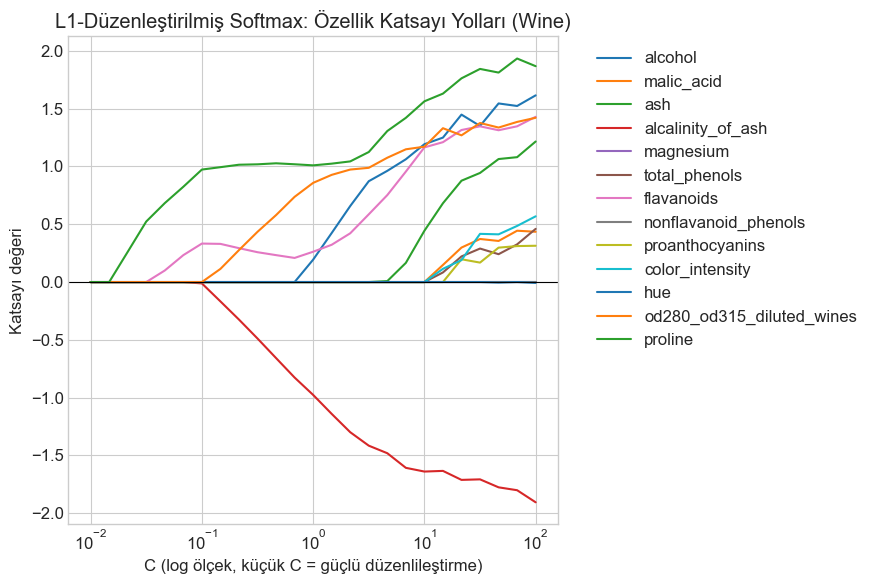

In [141]:
print("\n==== Egzersiz 1: Wine'da L1-Düzenleştirilmiş Softmax: Hangi Kimyasallar Elenir? ====")
C_wine_s = np.logspace(-2, 2, 25)
all_coefs = []
non_zero_counts = []
for C in C_wine_s:
    softmax_l1 = LogisticRegression(
        penalty='l1', 
        C=C, 
        solver='saga', 
        max_iter=20000, 
        tol=1e-3).fit(Xw_train_s, yw_train)
    all_coefs.append(softmax_l1.coef_[0])
    print(f"C={C:.4f} -> {np.sum(np.abs(softmax_l1.coef_[0]) > 1e-6)}/13 özellik sıfır olmayan katsayıya sahip")
    print(f"C={C:.4f} -> Katsayısı Sıfırlanmamış Özellikler : {[feat_cols_wine[i] for i in range(len(feat_cols_wine)) if np.abs(softmax_l1.coef_[0][i]) > 1e-6]}")
    non_zero_counts.append(np.sum(np.abs(softmax_l1.coef_[0]) > 1e-6))
    acc = accuracy_score(yw_test, softmax_l1.predict(Xw_test_s))
    print(f"  Test accuracy: {acc:.4f}\n")

fig, ax = plt.subplots(figsize=(9, 6))
for j in range(len(feat_cols_wine)):
    ax.plot(C_wine_s, [coef[j] for coef in all_coefs], label=feat_cols_wine[j])
ax.set_xscale('log')
ax.set_xlabel('C (log ölçek, küçük C = güçlü düzenlileştirme)')
ax.set_ylabel('Katsayı değeri')
ax.set_title('L1-Düzenleştirilmiş Softmax: Özellik Katsayı Yolları (Wine)')
ax.axhline(0, color='black', linewidth=0.8)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### **E2 (Python) — Breast Cancer'da LDA vs QDA: Özellik/Gözlem Oranı Değişince Ne Olur?**
Breast Cancer verisinde (30 özellik, 569 gözlem — Wine'dan hem daha çok özellik hem daha çok gözlem) `LinearDiscriminantAnalysis` ve `QuadraticDiscriminantAnalysis`'i `Xbc_train_s`/`Xbc_test_s` ile fit edip test accuracy'lerini karşılaştır. Sonucu Python 9'daki Wine karşılaştırmasıyla yan yana koy ve Bölüm 3.4'teki "az veri + çok parametre → QDA'nın overfit riski artar" kuralı bu iki veri setinde nasıl farklı sonuçlanıyor, yorumla (ikili sınıflandırmada QDA'nın 2 kovaryans matrisi tahmin ettiğini, 30 özellikte bunun her birinin 30×30 = 900 parametre olduğunu göz önünde bulundur).

In [142]:
print("\n==== Egzersiz 2: Breast Cancer'da LDA ve QDA Karşılaştırması ====")
qda_breast = QuadraticDiscriminantAnalysis().fit(Xbc_train_s, ybc_train)
lda_breast = LinearDiscriminantAnalysis().fit(Xbc_train_s, ybc_train)

comparison_breast_wine = pd.DataFrame({
    'Model-Veri Seti': ['LDA (Breast Cancer)', 'QDA (Breast Cancer)', 'LDA (Wine)', 'QDA (Wine)'],
    'Accuracy': [accuracy_score(ybc_test, lda_breast.predict(Xbc_test_s)),
                accuracy_score(ybc_test, qda_breast.predict(Xbc_test_s)),
                acc_lda,        # Wine LDA skoru
                acc_qda_full],
    'Parametre Sayısı (yaklaşık)': ['O(30)', 'O(3×30²)', 'O(13)', 'O(3×13²)'],
})
print(comparison_breast_wine.to_string(index=False))

print("\nYORUM: Breast Cancer'da parametre sayısı fazla olduğundan dolayı LinAlgWarning vererek QDA aşırı parametreleşmiş yani overfit olmuş ve LDA daha iyi performans göstermiştir. Wine veri setinde ise QDA, LDA'yı geçmiştir çünkü kovaryanslar farklıdır ve QDA bu farkı modelleyebilir.")


==== Egzersiz 2: Breast Cancer'da LDA ve QDA Karşılaştırması ====
    Model-Veri Seti  Accuracy Parametre Sayısı (yaklaşık)
LDA (Breast Cancer)  0.956140                       O(30)
QDA (Breast Cancer)  0.947368                    O(3×30²)
         LDA (Wine)  0.944444                       O(13)
         QDA (Wine)  1.000000                    O(3×13²)

YORUM: Breast Cancer'da parametre sayısı fazla olduğundan dolayı LinAlgWarning vererek QDA aşırı parametreleşmiş yani overfit olmuş ve LDA daha iyi performans göstermiştir. Wine veri setinde ise QDA, LDA'yı geçmiştir çünkü kovaryanslar farklıdır ve QDA bu farkı modelleyebilir.


/opt/anaconda3/lib/python3.13/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


### **E3 (Python) — SGDClassifier vs Tam-Batch LogisticRegression: Hız/Doğruluk Ödünleşimi**
Digits verisinde (`Xdig_train_s`/`Xdig_test_s`, 10 sınıf) hem `SGDClassifier(loss='log_loss')` hem de tam-batch `LogisticRegression`'ı `%%timeit` ile eğitim sürelerini ölçerek karşılaştır (Jupyter'da `%timeit model.fit(...)` kullanabilirsin). Accuracy farkı ne kadar, süre farkı ne kadar? Bölüm 5.1'deki "veri büyüdükçe SGD'nin avantajı artar" iddiası, bu nispeten küçük (1797 satır) veri setinde ne ölçüde gözlemlenebiliyor?

In [143]:
print("\n==== Egzersiz 3: SGDClassifier vs Tam-Batch Logistic Regression Karşılaştırması ====")
import timeit

sgd_log_loss_digit_time = timeit.timeit(lambda: SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, random_state=42).fit(Xdig_train_s, ydig_train), number=1)
logreg_digit_time = timeit.timeit(lambda: LogisticRegression(max_iter=1000, tol=1e-3, random_state=42).fit(Xdig_train_s, ydig_train), number=1)

sgd_acc = accuracy_score(ydig_test, SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, random_state=42).fit(Xdig_train_s, ydig_train).predict(Xdig_test_s))
logreg_acc = accuracy_score(ydig_test, LogisticRegression(max_iter=1000, tol=1e-3, random_state=42).fit(Xdig_train_s, ydig_train).predict(Xdig_test_s))

print(f"SGDClassifier (log_loss) Digits eğitimi süresi: {sgd_log_loss_digit_time:.4f} saniye")
print(f"Tam-batch LogisticRegression Digits eğitimi süresi: {logreg_digit_time:.4f} saniye")
print(f"SGDClassifier (log_loss) Digits test accuracy: {sgd_acc:.4f}")
print(f"Tam-batch LogisticRegression Digits test accuracy: {logreg_acc:.4f}")

print(f"\nYORUM: İki yöntem arası süre farkı = {logreg_digit_time - sgd_log_loss_digit_time:.4f} saniye. Doğruluk oranına baktığımızda da Logistic Regression modeli SGD'ye göre daha iyi performans göstermiştir. Küçük veri olduğundan dolayı tam-batch yöntem daha iyi sonuç vermiştir. Büyük veri setlerinde ise SGD daha hızlı ve yeterli doğruluk sağlayabilir.")


==== Egzersiz 3: SGDClassifier vs Tam-Batch Logistic Regression Karşılaştırması ====
SGDClassifier (log_loss) Digits eğitimi süresi: 0.2012 saniye
Tam-batch LogisticRegression Digits eğitimi süresi: 0.0121 saniye
SGDClassifier (log_loss) Digits test accuracy: 0.9444
Tam-batch LogisticRegression Digits test accuracy: 0.9667

YORUM: İki yöntem arası süre farkı = -0.1891 saniye. Doğruluk oranına baktığımızda da Logistic Regression modeli SGD'ye göre daha iyi performans göstermiştir. Küçük veri olduğundan dolayı tam-batch yöntem daha iyi sonuç vermiştir. Büyük veri setlerinde ise SGD daha hızlı ve yeterli doğruluk sağlayabilir.


### **E4 (R) — `glm` ile Tam Özellik Setinde Ayrışma (Separation) Sorununu Gözlemleme**
`glm(diagnosis ~ ., data = bc[, !(names(bc) %in% c("target"))], family = binomial)` ile Breast Cancer'ın **tüm 30 özelliğiyle** bir model fit et (R Bölüm A'da sadece 2 özellik kullanmıştık). R'ın verdiği uyarıya (`fitted probabilities numerically 0 or 1 occurred`) dikkat et — bu, Python 3'ün markdown yorumunda bahsedilen quasi-separation sorununun R'daki karşılığıdır. Ardından `glmnet` paketiyle (bkz. `02_linear_regression_family`'deki R bölümü) `alpha=0` (Ridge) ile düzenlileştirilmiş bir versiyonunu fit et — uyarı kayboluyor mu? Katsayılar nasıl değişiyor?

In [144]:
%%R
library(glmnet)

# Standart Lojistik Regresyon (Mükemmel ayrışma uyarısı verebilir)
bc_glm_full <- glm(diagnosis ~ ., data = bc[, !(names(bc) %in% c("target"))], family = binomial)
cat("Standart Lojistik Regresyon Odds Ratios\n")
print(round(exp(cbind(OddsRatio = coef(bc_glm_full), confint.default(bc_glm_full))), 4))

cat("\nYORUM: Tüm özellikleri soktuğumuzda da yukarıda aldığımız Quasi-Separation uyarısıyla karşılaştık. Model tahminleri mükemmel ayrışma gösterdiği için katsayılar çok büyük değerlere ulaştı ve güven aralıkları sonsuz oldu. Bu nedenle, L1 veya L2 düzenlileştirme kullanmak daha güvenilir sonuçlar verebilir.\n")

# Ridge (L2) Düzenlileştirilmiş Lineer Regresyon
X_bc_matrix <- as.matrix(bc[, !(names(bc) %in% c("target"))], data = bc)
y_bc_vector <- bc$diagnosis
ridge_model <- glmnet(X_bc_matrix, y_bc_vector, family = "binomial", alpha = 0)  # alpha=0 -> Ridge (L2)
cat("\nRidge (L2) Düzenlileştirilmiş Lojistik Regresyon Katsayıları\n")
print(round(coef(ridge_model, s = 0.01), 4))  # s=0.01 -> düzenlileştirme parametresi

cat("\nYORUM: Ridge düzenlileştirme, katsayıları küçültür ve aşırı parametreleşmeyi önler. Bu sayede model daha stabil hale gelir ve tahminler daha güvenilir olur. Hiçbiri sıfırlanmadı ve Quasi-Separation uyarısı alınmadı.\n")

Standart Lojistik Regresyon Odds Ratios
                        OddsRatio 2.5 % 97.5 %
(Intercept)                     0     0      0
mean_radius                   Inf   Inf    Inf
mean_texture                  Inf   Inf    Inf
mean_perimeter                Inf   Inf    Inf
mean_area                       0     0      0
mean_smoothness                 0     0      0
mean_compactness                0     0      0
mean_concavity                Inf     0    Inf
mean_concave_points             0     0      0
mean_symmetry                 Inf   Inf    Inf
mean_fractal_dimension          0     0      0
radius_error                  Inf   Inf    Inf
texture_error                 Inf   Inf    Inf
perimeter_error               Inf   Inf    Inf
area_error                      0     0      0
smoothness_error              Inf   Inf    Inf
compactness_error               0     0      0
concavity_error               Inf   Inf    Inf
concave_points_error            0     0      0
symmetry_error      

In addition: Warning messages:
1: glm.fit: algorithm did not converge 
2: glm.fit: fitted probabilities numerically 0 or 1 occurred 
3: In storage.mode(x) <- "double" : NAs introduced by coercion


### **E5 (SQL) — Digits: Hangi Piksel En Ayırt Edici?**
`digits_tbl` üzerinde, orta bölgedeki birkaç piksel sütunu (örn. `px_3_3`, `px_4_4`) için her rakam (`target`, 0-9) sınıfının o pikseldeki ortalama yoğunluğunu (`AVG`) hesapla (`GROUP BY target`). Hangi piksellerde sınıflar arası ortalama fark en büyük (bu pikselin ayırt ediciliği yüksek demektir), hangilerinde tüm sınıflar birbirine yakın (bu piksel ayırt edici değildir — örn. görüntünün köşesi, hep boş)? `STDDEV` fonksiyonuyla sınıflar-arası ortalamaların kendi standart sapmasını hesaplayarak bunu tek bir sayıya indirgeyebilirsin.

In [145]:
print("\n==== Egzersiz 5: Digits: Hangi Piksel En Ayırt Edici? ====")
sql_pixel = '''
WITH pixel_stats AS (
    SELECT
        target,
        px_3_3,
        px_3_4,
        px_4_4,
        px_5_5,
        px_6_6
    FROM digits_tbl
)
SELECT
    target,
    -- Ortalama Değerler
    ROUND(AVG(px_3_3), 2) AS avg_3_3,
    ROUND(AVG(px_3_4), 2) AS avg_3_4,
    ROUND(AVG(px_4_4), 2) AS avg_4_4,
    ROUND(AVG(px_5_5), 2) AS avg_5_5,
    ROUND(AVG(px_6_6), 2) AS avg_6_6,
    -- Standart Sapma Değerleri (Ayırt edicilik/Değişkenlik analizi için)
    ROUND(STDDEV(px_3_3), 2) AS std_3_3,
    ROUND(STDDEV(px_3_4), 2) AS std_3_4,
    ROUND(STDDEV(px_4_4), 2) AS std_4_4,
    ROUND(STDDEV(px_5_5), 2) AS std_5_5,
    ROUND(STDDEV(px_6_6), 2) AS std_6_6
FROM pixel_stats
GROUP BY target
ORDER BY target;
'''
print(con.execute(sql_pixel).df().to_string(index=False))


==== Egzersiz 5: Digits: Hangi Piksel En Ayırt Edici? ====
 target  avg_3_3  avg_3_4  avg_4_4  avg_5_5  avg_6_6  std_3_3  std_3_4  std_4_4  std_5_5  std_6_6
      0     1.99     0.14     0.04    11.31     2.42     3.44     0.58     0.33     3.68     3.09
      1    14.29    13.86    13.69     5.88     2.05     3.79     3.53     3.49     5.86     3.84
      2     4.74    12.10    10.49     2.06     7.18     4.82     4.11     4.51     3.41     4.73
      3     8.94    14.27    12.05    12.14     5.93     5.32     3.01     3.98     3.75     4.56
      4     6.35     7.35    13.02    10.44     0.02     4.74     6.06     4.19     4.90     0.15
      5    12.04     8.97     8.84     8.18     1.34     4.09     5.65     5.76     5.79     2.97
      6     8.11     3.88    12.03    10.12    10.78     5.60     4.92     4.33     4.55     4.35
      7     6.25    12.13    14.77     3.88     0.00     5.07     4.32     2.35     4.72     0.00
      8    13.22    13.32    12.92     8.48     2.32     3

### **E6 (Python — Sentez) — Dört Modelin Karar Sınırını Aynı Grafikte Karşılaştır**
Breast Cancer'dan kendi seçtiğin 2 özellikle (örn. `mean_radius`, `mean_texture`) `LogisticRegression`, `LinearDiscriminantAnalysis`, `QuadraticDiscriminantAnalysis` ve `Perceptron`'u fit edip, `plt.subplots(2, 2, ...)` ile 4 karar sınırını yan yana çiz (Python 3 ve Python 8'deki `meshgrid`+`contourf` deseni işine yarayacak). Hangi modelin sınırı hangisine en çok benziyor (Bölüm 1'deki "hepsi doğrusal, QDA hariç" tablosunu doğruluyor mu)? Perceptron'un olasılık üretmediğini unutma — onun için `predict_proba` yerine `predict`'in kendisini görselleştirmen gerekecek.

Logistic Regression (2 özellik) accuracy: 0.8664
LinearDiscriminantAnalysis (2 özellik) accuracy: 0.8032
QuadraticDiscriminantAnalysis (2 özellik) accuracy: 0.8647
Perceptron (2 özellik) accuracy: 0.5712


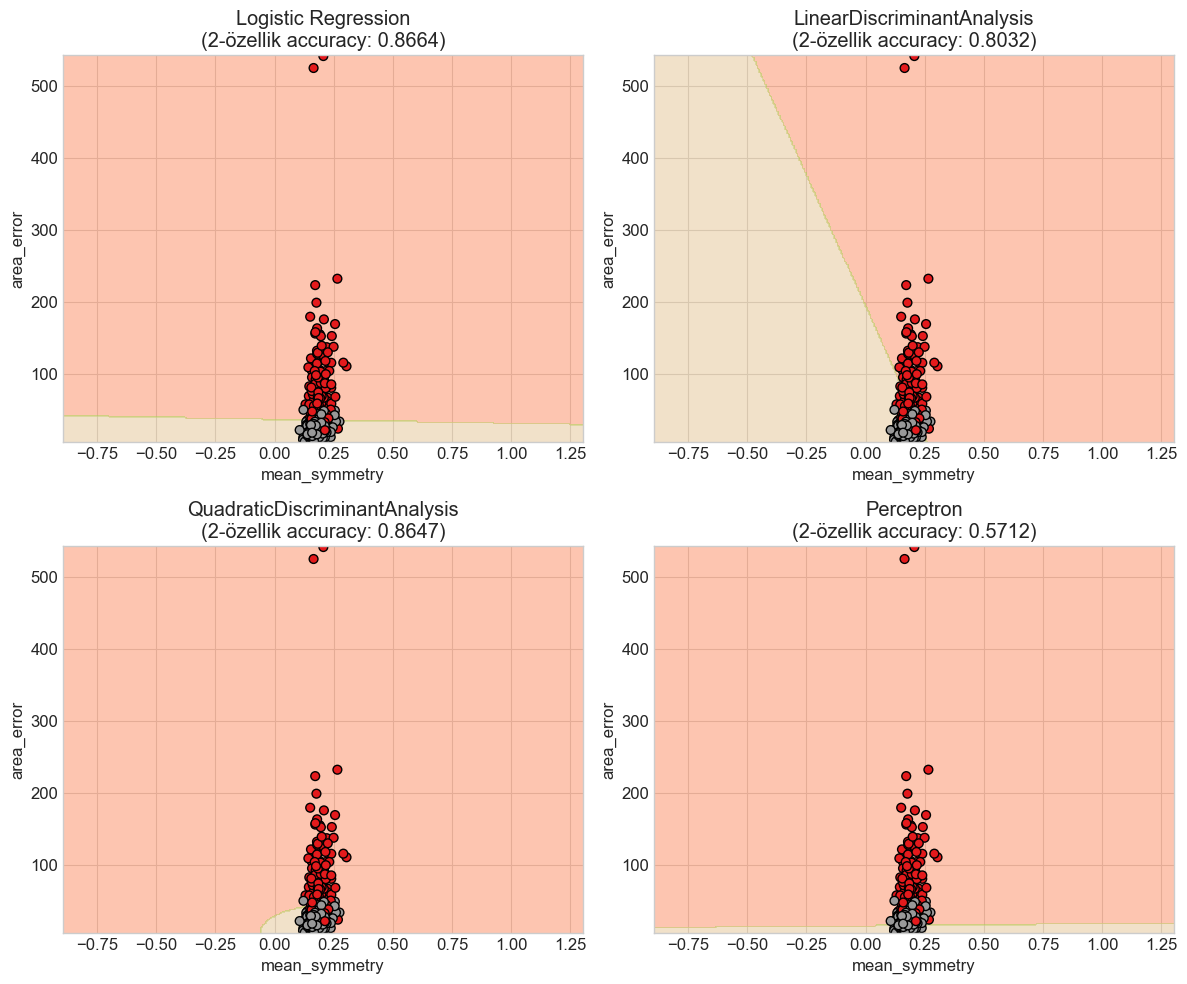


YORUM: 2 özellikli de Logistic Reg, LDA, Perceptron düz çizgi çizerken; QDA ise eğrisel bir sınır çiziyor. Bu, QDA'nın sınıflar arasındaki kovaryans farklılıklarını modelleyebilme yeteneğini gösteriyor. Ancak, 2 özellikli veri setinde ise LDA LR ve QDA yakın iken, Perceptron neredeyse yazı turaya düşmüş.


In [146]:
cols= 'mean_symmetry', 'area_error'
X_bc_2feat = bc[list(cols)].values
y_bc_2feat = bc['target'].values

models_2feat = {
    'Logistic Regression': LogisticRegression(max_iter=1000, tol=1e-3, random_state=42),
    'LinearDiscriminantAnalysis': LinearDiscriminantAnalysis(),
    'QuadraticDiscriminantAnalysis': QuadraticDiscriminantAnalysis(),
    'Perceptron': Perceptron(max_iter=1000, tol=1e-3, random_state=42),
}

plt.figure(figsize=(12, 10))
xx, yy = np.meshgrid(np.linspace(X_bc_2feat[:, 0].min() - 1, X_bc_2feat[:, 0].max() + 1, 300),
                     np.linspace(X_bc_2feat[:, 1].min() - 1, X_bc_2feat[:, 1].max() + 1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

for name, model in models_2feat.items():
    model.fit(X_bc_2feat, y_bc_2feat)
    acc = accuracy_score(y_bc_2feat, model.predict(X_bc_2feat))
    print(f"{name} (2 özellik) accuracy: {acc:.4f}")
    Z = model.predict(grid).reshape(xx.shape)
    plt.subplot(2, 2, list(models_2feat.keys()).index(name) + 1)
    plt.contourf(xx, yy, Z, levels=2, cmap='Set2', alpha=0.5)
    plt.scatter(X_bc_2feat[:, 0], X_bc_2feat[:, 1], c=y_bc_2feat, cmap='Set1', edgecolor='k', s=40)
    plt.title(f"{name}\n(2-özellik accuracy: {acc:.4f})")
    plt.xlabel(cols[0])
    plt.ylabel(cols[1])
plt.tight_layout()
plt.show()

print("\nYORUM: 2 özellikli de Logistic Reg, LDA, Perceptron düz çizgi çizerken; QDA ise eğrisel bir sınır çiziyor. Bu, QDA'nın sınıflar arasındaki kovaryans farklılıklarını modelleyebilme yeteneğini gösteriyor. Ancak, 2 özellikli veri setinde ise LDA LR ve QDA yakın iken, Perceptron neredeyse yazı turaya düşmüş.")


---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Breast Cancer Wisconsin (Diagnostic) Data Set (UCI ML Repository)](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) | Veri Seti | Kullanılan 1. veri seti — orijinal akademik kaynak (Wolberg, Street & Mangasarian) |
| [scikit-learn — `sklearn.datasets.load_breast_cancer`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) | Veri Seti | İndirme için kullanılan güvenilir, ağ erişimi gerektirmeyen kaynak |
| [Wine Recognition Data Set (UCI ML Repository)](https://archive.ics.uci.edu/dataset/109/wine) | Veri Seti | Kullanılan 2. veri seti — orijinal akademik kaynak (Forina et al.) |
| [scikit-learn — `sklearn.datasets.load_wine`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html) | Veri Seti | İndirme için kullanılan güvenilir kaynak |
| [Optical Recognition of Handwritten Digits Data Set (UCI ML Repository)](https://archive.ics.uci.edu/dataset/80/optical+recognition+of+handwritten+digits) | Veri Seti | Kullanılan 3. veri seti — orijinal akademik kaynak |
| [scikit-learn — `sklearn.datasets.load_digits`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html) | Veri Seti | İndirme için kullanılan güvenilir kaynak |
| [Fisher, R.A. (1936). "The Use of Multiple Measurements in Taxonomic Problems", *Annals of Eugenics*, 7(2)](https://onlinelibrary.wiley.com/doi/10.1111/j.1469-1809.1936.tb02137.x) | Teori | LDA'nın orijinal makalesi — Bölüm 3.2/3.4'teki tarihsel referans |
| [Rosenblatt, F. (1958). "The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain", *Psychological Review*, 65(6)](https://psycnet.apa.org/doi/10.1037/h0042519) | Teori | Perceptron'un orijinal makalesi — Bölüm 4.1'deki tarihsel referans |
| [Minsky, M. & Papert, S. (1969). *Perceptrons: An Introduction to Computational Geometry*, MIT Press](https://mitpress.mit.edu/9780262631112/perceptrons/) | Teori | XOR/doğrusal-ayrılamazlık eleştirisi — Bölüm 4.2 |
| [scikit-learn — Logistic Regression (User Guide)](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression) | Resmi Dok. | Bölüm 2-6'daki `LogisticRegression` API'si (C, l1_ratio, çok sınıflı davranış) |
| [scikit-learn — Linear and Quadratic Discriminant Analysis](https://scikit-learn.org/stable/modules/lda_qda.html) | Resmi Dok. | Bölüm 7-9'daki `LinearDiscriminantAnalysis`/`QuadraticDiscriminantAnalysis` API'leri ve matematiksel türetim |
| [scikit-learn — `Perceptron`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html) | Resmi Dok. | Bölüm 10-11'deki API |
| [scikit-learn — Stochastic Gradient Descent (User Guide)](https://scikit-learn.org/stable/modules/sgd.html) | Resmi Dok. | Bölüm 12-14'teki `SGDClassifier`, `loss`/`learning_rate` parametreleri, `partial_fit` |
| [statsmodels — Logit](https://www.statsmodels.org/stable/generated/statsmodels.discrete.discrete_model.Logit.html) | Resmi Dok. | Python 3'teki p-değeri/güven aralığı analizi |
| [R — `stats::glm`](https://stat.ethz.ch/R-manual/R-devel/library/stats/html/glm.html) | Resmi Dok. | R Bölüm A'daki ikili lojistik regresyon |
| [R — `nnet::multinom` (CRAN)](https://cran.r-project.org/web/packages/nnet/index.html) | Resmi Dok. | R Bölüm B'deki çok sınıflı lojistik regresyon |
| [R — `MASS::lda` / `MASS::qda` (CRAN)](https://cran.r-project.org/web/packages/MASS/index.html) | Resmi Dok. | R Bölüm C — Venables & Ripley'nin klasik `MASS` paketi, LDA/QDA'nın R'daki standart implementasyonu |
| [DuckDB — Aggregate Functions (`VAR_POP`, `COVAR_POP`, `MEDIAN`) ve Window Functions (`NTILE`)](https://duckdb.org/docs/sql/functions/aggregates.html) | Resmi Dok. | SQL bölümündeki tüm istatistiksel toplama/pencere fonksiyonları |
| [James, Witten, Hastie, Tibshirani — *An Introduction to Statistical Learning* (ücretsiz, statlearning.com), Bölüm 4](https://www.statlearning.com/) | Kitap | Lojistik regresyon, LDA/QDA teorisi ve karşılaştırmalı bias-variance tartışması |
| [Altman, E.I. (1968). "Financial Ratios, Discriminant Analysis and the Prediction of Corporate Bankruptcy", *The Journal of Finance*, 23(4)](https://onlinelibrary.wiley.com/doi/10.1111/j.1540-6261.1968.tb00843.x) | Endüstri Örneği | Z-Score modeli — Bölüm 3.4'teki finans/kredi risk örneği |